# FMA-small + MusicCaps — Quick EDA

Two separate datasets — different tracks, different sources, no shared
clips — so this notebook explores them independently rather than trying
to join them. Run in Colab/Kaggle with real internet access; CPU runtime
is fine for EDA.

**How they map onto the four tasks:**
- **Task 1 (BERT tags)** — MusicCaps captions / aspect-lists as the
  caption→tag proxy task the brief explicitly allows.
- **Task 2 (GNN structure)** — FMA-small audio + its 8 balanced genre
  labels, exactly the pairing the brief names for this task.
- **Task 3 (fusion)** — needs an audio graph *and* text for the same
  clip. FMA has no captions and MusicCaps captions don't describe FMA
  tracks, so pick one: (a) fuse FMA audio graphs with FMA's own
  genre/tag metadata as pseudo-text, or (b) build graphs from
  MusicCaps' own audio and fuse with its own captions. Decide after
  both EDAs below — there's a note at the end.
- **Task 4 (contrastive retrieval)** — MusicCaps only; it's the one
  dataset here with real audio-caption pairs to contrast against.


In [ ]:
!pip install -q librosa soundfile datasets yt-dlp matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 4.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.4 MB/s eta 0:00:00a 0:00:01


## Part A — FMA-small

### A.1 Download

In [ ]:
import os

BASE = "https://os.unil.cloud.switch.ch/fma"
os.makedirs("data/raw/fma", exist_ok=True)
%cd data/raw/fma

!wget -nc {BASE}/fma_metadata.zip
!wget -c {BASE}/fma_small.zip
!unzip -q -o fma_metadata.zip
!unzip -q -o fma_small.zip

%cd ../../..

/kaggle/working/data/raw/fma
--2026-09-06 11:55:06--  https://os.unil.cloud.switch.ch/fma/fma_metadata.zip
Resolving os.unil.cloud.switch.ch (os.unil.cloud.switch.ch)... 86.119.28.16, 2001:620:5ca1:201::214
Connecting to os.unil.cloud.switch.ch (os.unil.cloud.switch.ch)|86.119.28.16|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 358412441 (342M) [application/zip]
Saving to: ‘fma_metadata.zip’

fma_metadata.zip    100%[===================>] 341.81M  27.0MB/s    in 14s     

2026-09-06 11:55:20 (24.6 MB/s) - ‘fma_metadata.zip’ saved [358412441/358412441]

--2026-09-06 11:55:20--  https://os.unil.cloud.switch.ch/fma/fma_small.zip
Resolving os.unil.cloud.switch.ch (os.unil.cloud.switch.ch)... 86.119.28.16, 2001:620:5ca1:201::214
Connecting to os.unil.cloud.switch.ch (os.unil.cloud.switch.ch)|86.119.28.16|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7679594875 (7.2G) [application/zip]
Saving to: ‘fma_small.zip’

fma_small.zip       100

### A.2 Load metadata

`tracks.csv` ships with a 3-level column header and needs a bit of
massaging (this mirrors the official loader in `mdeff/fma`'s `utils.py`
rather than reinventing it).

In [ ]:
import ast
import pandas as pd

def load_fma_tracks(filepath):
    tracks = pd.read_csv(filepath, index_col=0, header=[0, 1])
    for col in [("track", "tags"), ("album", "tags"), ("artist", "tags"),
                ("track", "genres"), ("track", "genres_all")]:
        tracks[col] = tracks[col].map(ast.literal_eval)
    return tracks

tracks = load_fma_tracks("data/raw/fma/fma_metadata/tracks.csv")
small = tracks[tracks["set", "subset"] == "small"]
print(f"{len(small)} tracks in the small subset")
small["track", "genre_top"].value_counts()

8000 tracks in the small subset


(track, genre_top)
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64

In [ ]:
print("Missing FMA genre labels:")
print(small["track", "genre_top"].isnull().sum())

Missing FMA genre labels:
0


### A.3 Genre balance

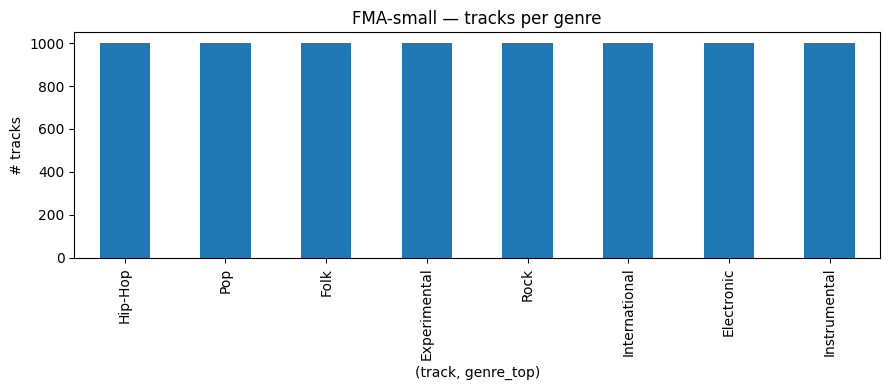

In [ ]:
import matplotlib.pyplot as plt

small["track", "genre_top"].value_counts().plot(kind="bar", figsize=(9, 4))
plt.title("FMA-small — tracks per genre")
plt.ylabel("# tracks")
plt.tight_layout()
plt.show()

### A.4 Audio sanity check

In [ ]:
def fma_audio_path(track_id, audio_dir="data/raw/fma/fma_small"):
    tid_str = f"{track_id:06d}"
    return f"{audio_dir}/{tid_str[:3]}/{tid_str}.mp3"

import glob
mp3_files = glob.glob("data/raw/fma/fma_small/*/*.mp3")
print(f"Found {len(mp3_files)} mp3 files on disk (expect ~8,000)")
print(mp3_files[:5])

Found 8000 mp3 files on disk (expect ~8,000)
['data/raw/fma/fma_small/054/054037.mp3', 'data/raw/fma/fma_small/054/054576.mp3', 'data/raw/fma/fma_small/054/054031.mp3', 'data/raw/fma/fma_small/054/054568.mp3', 'data/raw/fma/fma_small/054/054664.mp3']


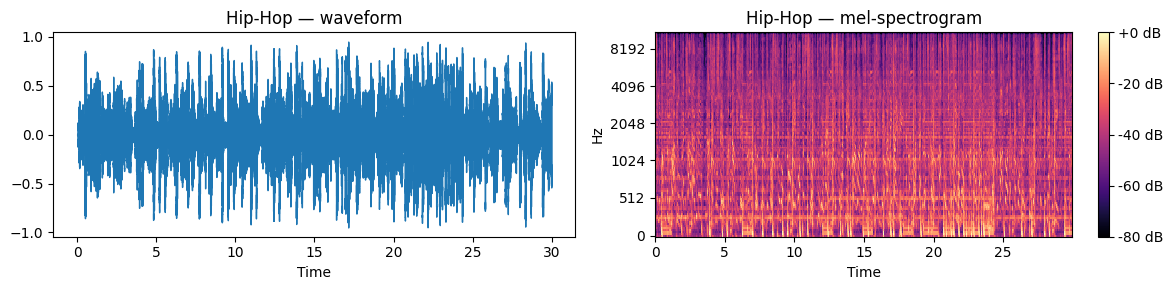

duration: 30.0s, sr: 22050


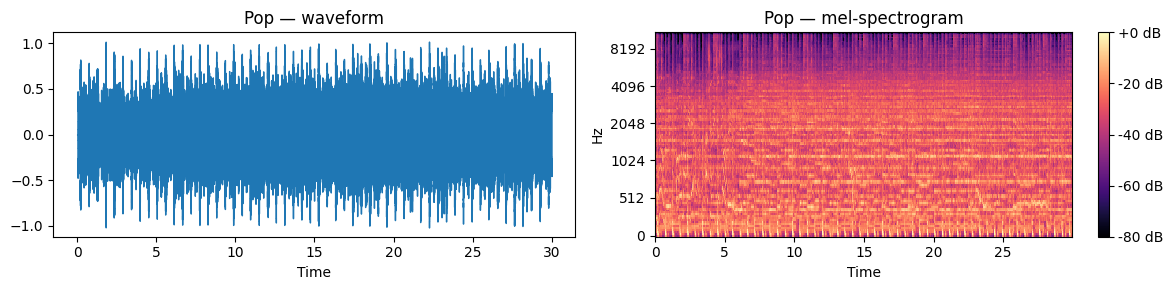

duration: 30.0s, sr: 22050


In [ ]:
import librosa, librosa.display
import numpy as np

def show_clip(mp3_path, title):
    y, sr = librosa.load(mp3_path, sr=22050, mono=True)
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    librosa.display.waveshow(y, sr=sr, ax=ax[0])
    ax[0].set_title(f"{title} — waveform")
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=ax[1])
    ax[1].set_title(f"{title} — mel-spectrogram")
    fig.colorbar(img, ax=ax[1], format="%+2.0f dB")
    plt.tight_layout()
    plt.show()
    print(f"duration: {len(y)/sr:.1f}s, sr: {sr}")

sample_genres = small["track", "genre_top"].dropna().unique()[:2]
for genre in sample_genres:
    tid = small[small["track", "genre_top"] == genre].index[0]
    path = fma_audio_path(tid)
    if os.path.exists(path):
        show_clip(path, genre)
    else:
        print(f"missing on disk: {path} (see the FMA errata link if this keeps happening)")

## Part B — MusicCaps

### B.1 Captions (fast — no audio yet)

Pulls just the caption table first, since that's small (~3 MB) and lets
you explore the text side immediately, before committing to the slow
YouTube download in B.3.

In [ ]:
from datasets import load_dataset

mc = load_dataset("google/MusicCaps")
print(mc)
split = "train" if "train" in mc else list(mc.keys())[0]
caps_df = mc[split].to_pandas()
print(caps_df.columns.tolist())
caps_df.head()

DatasetDict({
    train: Dataset({
        features: ['ytid', 'start_s', 'end_s', 'audioset_positive_labels', 'aspect_list', 'caption', 'author_id', 'is_balanced_subset', 'is_audioset_eval'],
        num_rows: 5521
    })
})
['ytid', 'start_s', 'end_s', 'audioset_positive_labels', 'aspect_list', 'caption', 'author_id', 'is_balanced_subset', 'is_audioset_eval']


,ytid,start_s,end_s,audioset_positive_labels,aspect_list,caption,author_id,is_balanced_subset,is_audioset_eval
0,-0Gj8-vB1q4,30,40,"/m/0140xf,/m/02cjck,/m/04rlf","['low quality', 'sustained strings melody', 's...",The low quality recording features a ballad so...,4,False,True
1,-0SdAVK79lg,30,40,"/m/0155w,/m/01lyv,/m/0342h,/m/042v_gx,/m/04rlf...","['guitar song', 'piano backing', 'simple percu...",This song features an electric guitar as the m...,0,False,False
2,-0vPFx-wRRI,30,40,"/m/025_jnm,/m/04rlf","['amateur recording', 'finger snipping', 'male...",a male voice is singing a melody with changing...,6,False,True
3,-0xzrMun0Rs,30,40,"/m/01g90h,/m/04rlf","['backing track', 'jazzy', 'digital drums', 'p...",This song contains digital drums playing a sim...,6,False,True
4,-1LrH01Ei1w,30,40,"/m/02p0sh1,/m/04rlf","['rubab instrument', 'repetitive melody on dif...",This song features a rubber instrument being p...,0,False,False


In [ ]:
print("Missing values in MusicCaps:")
print(caps_df.isnull().sum())

print("\nDuplicate YouTube IDs:")
print(caps_df["ytid"].duplicated().sum())

Missing values in MusicCaps:
ytid                        0
start_s                     0
end_s                       0
audioset_positive_labels    0
aspect_list                 0
caption                     0
author_id                   0
is_balanced_subset          0
is_audioset_eval            0
dtype: int64

Duplicate YouTube IDs:
0


### B.2 Caption + aspect-list exploration

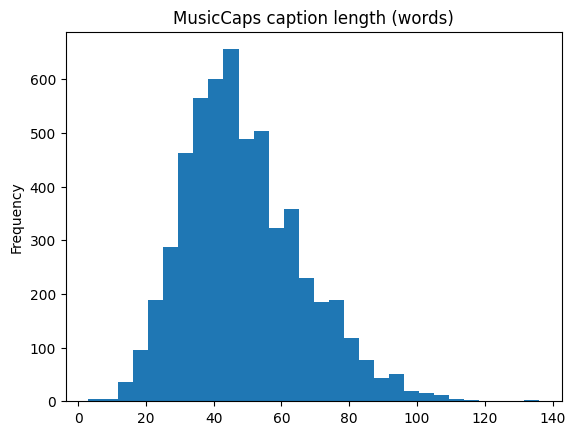

count    5521.000000
mean       48.968303
std        17.329780
min         3.000000
25%        37.000000
50%        46.000000
75%        60.000000
max       136.000000
Name: caption_len, dtype: float64
- Someone is playing a solo on a clean e-guitar along with a backing track that sounds like a slow soulful, sad ballad with strings,bass, acoustic drums and an e-guitar strumming single chords as a rhyt
- This song is a vocalisation by a female singer. The tempo is medium with an upbeat electronic guitar harmony, funky bass guitar, slick drumming and acoustic guitar accompaniment. The music is simple, 
- An acoustic drum is playing a groove with crash hits and a double-bass drum along with the e-bass and an e-guitar playing bass notes along with the complex kickdrum. A oriental sounding string and bra


In [ ]:
caps_df["caption_len"] = caps_df["caption"].str.split().str.len()
caps_df["caption_len"].plot(kind="hist", bins=30, title="MusicCaps caption length (words)")
plt.show()
print(caps_df["caption_len"].describe())

for c in caps_df["caption"].sample(3, random_state=0):
    print("-", c[:200])

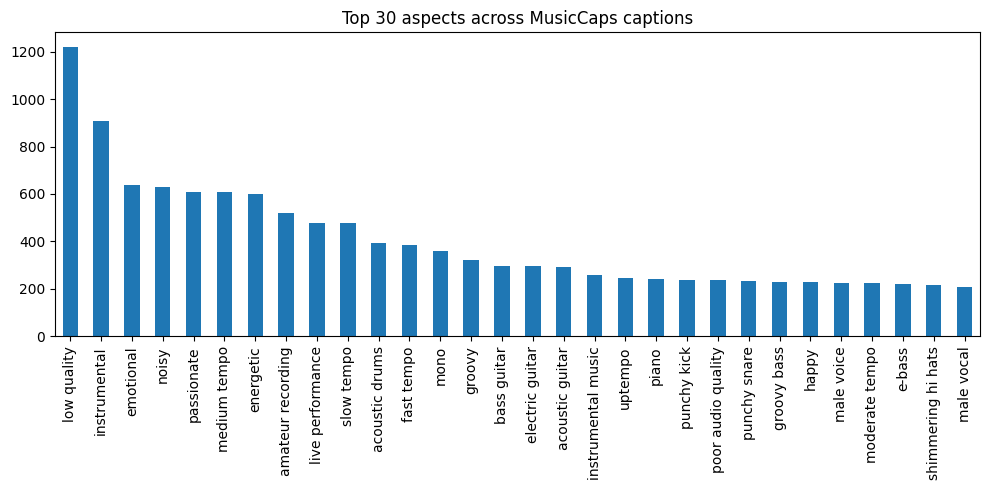

In [ ]:
# aspect_list contains multiple short descriptive labels for each MusicCaps example
# your closest thing to "tags" for the Task 1 proxy task.
from collections import Counter

aspects = Counter()
for row in caps_df["aspect_list"].dropna():
    for a in row.strip("[]").replace("'", "").split(","):
        aspects[a.strip()] += 1

pd.Series(dict(aspects.most_common(30))).plot(kind="bar", figsize=(10, 5))
plt.title("Top 30 aspects across MusicCaps captions")
plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

all_aspects = []

for row in caps_df["aspect_list"].dropna():
    cleaned = row.strip("[]").replace("'", "")
    aspects = [a.strip() for a in cleaned.split(",") if a.strip()]
    all_aspects.extend(aspects)

aspect_counts = Counter(all_aspects)

print("Total unique aspects:", len(aspect_counts))
print("\nTop 30 most common aspects:")

for tag, count in aspect_counts.most_common(30):
    print(f"{tag}: {count}")

Total unique aspects: 13219

Top 30 most common aspects:
low quality: 1220
instrumental: 908
emotional: 636
noisy: 628
passionate: 610
medium tempo: 608
energetic: 599
amateur recording: 518
live performance: 477
slow tempo: 476
acoustic drums: 394
fast tempo: 383
mono: 358
groovy: 321
bass guitar: 297
electric guitar: 297
acoustic guitar: 292
instrumental music: 260
uptempo: 247
piano: 240
punchy kick: 239
poor audio quality: 236
punchy snare: 235
groovy bass: 229
happy: 228
male voice: 224
moderate tempo: 224
e-bass: 222
shimmering hi hats: 217
male vocal: 208


In [ ]:
top20 = [tag for tag, count in aspect_counts.most_common(20)]
top30 = [tag for tag, count in aspect_counts.most_common(30)]
top50 = [tag for tag, count in aspect_counts.most_common(50)]

def count_rows_with_any_tag(tag_list):
    count = 0

    for row in caps_df["aspect_list"].dropna():
        cleaned = row.strip("[]").replace("'", "")
        aspects = [a.strip() for a in cleaned.split(",") if a.strip()]

        if any(tag in aspects for tag in tag_list):
            count += 1

    return count

print("Rows covered by Top 20 tags:", count_rows_with_any_tag(top20))
print("Rows covered by Top 30 tags:", count_rows_with_any_tag(top30))
print("Rows covered by Top 50 tags:", count_rows_with_any_tag(top50))
print("Total MusicCaps rows:", len(caps_df))

Rows covered by Top 20 tags: 4517
Rows covered by Top 30 tags: 4786
Rows covered by Top 50 tags: 4995
Total MusicCaps rows: 5521


In [ ]:
print(caps_df.shape)
print(len(caps_df))

(5521, 10)
5521


In [ ]:
top50_counts = aspect_counts.most_common(50)

for i, (tag, count) in enumerate(top50_counts, start=1):
    print(f"{i:2d}. {tag}: {count}")

 1. low quality: 1220
 2. instrumental: 908
 3. emotional: 636
 4. noisy: 628
 5. passionate: 610
 6. medium tempo: 608
 7. energetic: 599
 8. amateur recording: 518
 9. live performance: 477
10. slow tempo: 476
11. acoustic drums: 394
12. fast tempo: 383
13. mono: 358
14. groovy: 321
15. bass guitar: 297
16. electric guitar: 297
17. acoustic guitar: 292
18. instrumental music: 260
19. uptempo: 247
20. piano: 240
21. punchy kick: 239
22. poor audio quality: 236
23. punchy snare: 235
24. groovy bass: 229
25. happy: 228
26. male voice: 224
27. moderate tempo: 224
28. e-bass: 222
29. shimmering hi hats: 217
30. male vocal: 208
31. rock: 207
32. percussion: 206
33. no voices: 204
34. youthful: 202
35. pop: 199
36. male singer: 195
37. spirited: 193
38. romantic: 191
39. electronic drums: 188
40. exciting: 182
41. upbeat: 181
42. bass: 178
43. loud: 171
44. mellow: 164
45. keyboard harmony: 162
46. fun: 161
47. cheerful: 157
48. easygoing: 155
49. flat male vocal: 151
50. e-guitar: 147


### MusicCaps Aspect Label Cleaning

The raw MusicCaps aspect labels contain semantically similar or duplicate terms
(e.g., "male voice", "male vocal", "male singer"). These should be normalized
before selecting the final label set for Task 1.

In [ ]:
import ast

# Convert aspect_list from string representation to Python list
def parse_aspects(x):
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except:
        return []

caps_df["parsed_aspects"] = caps_df["aspect_list"].apply(parse_aspects)

In [ ]:
label_map = {
    "male voice": "male vocal",
    "male singer": "male vocal",

    "e-guitar": "electric guitar",

    "e-bass": "bass guitar",
    "bass": "bass guitar",

    "instrumental music": "instrumental",

    "moderate tempo": "medium tempo",
    "uptempo": "fast tempo"
}

In [ ]:
def normalize_aspects(aspects):
    cleaned = []

    for tag in aspects:
        tag = tag.strip().lower()
        tag = label_map.get(tag, tag)

        if tag not in cleaned:
            cleaned.append(tag)

    return cleaned

caps_df["normalized_aspects"] = caps_df["parsed_aspects"].apply(normalize_aspects)

In [ ]:
from collections import Counter

normalized_counts = Counter()

for aspects in caps_df["normalized_aspects"]:
    normalized_counts.update(aspects)

for i, (tag, count) in enumerate(normalized_counts.most_common(50), start=1):
    print(f"{i:2d}. {tag}: {count}")

 1. low quality: 1217
 2. instrumental: 1148
 3. medium tempo: 819
 4. bass guitar: 696
 5. fast tempo: 627
 6. noisy: 626
 7. male vocal: 625
 8. emotional: 620
 9. energetic: 593
10. passionate: 592
11. amateur recording: 515
12. slow tempo: 473
13. live performance: 468
14. electric guitar: 444
15. acoustic drums: 393
16. mono: 357
17. groovy: 321
18. acoustic guitar: 290
19. piano: 239
20. punchy kick: 236
21. punchy snare: 235
22. groovy bass: 228
23. happy: 225
24. poor audio quality: 221
25. shimmering hi hats: 217
26. rock: 207
27. percussion: 206
28. no voices: 202
29. pop: 197
30. youthful: 189
31. electronic drums: 188
32. spirited: 185
33. upbeat: 181
34. romantic: 177
35. exciting: 177
36. loud: 168
37. fun: 160
38. keyboard harmony: 159
39. mellow: 158
40. easygoing: 154
41. flat male vocal: 151
42. cheerful: 150
43. relaxing: 144
44. calming: 139
45. no other instruments: 137
46. keyboard: 135
47. intense: 134
48. enthusiastic: 131
49. no singer: 130
50. melodic singing:

In [ ]:
NUM_LABELS = 30

task1_labels = [
    tag for tag, count in normalized_counts.most_common(NUM_LABELS)
]

print("Task 1 labels:")
for i, tag in enumerate(task1_labels, start=1):
    print(f"{i:2d}. {tag}")

Task 1 labels:
 1. low quality
 2. instrumental
 3. medium tempo
 4. bass guitar
 5. fast tempo
 6. noisy
 7. male vocal
 8. emotional
 9. energetic
10. passionate
11. amateur recording
12. slow tempo
13. live performance
14. electric guitar
15. acoustic drums
16. mono
17. groovy
18. acoustic guitar
19. piano
20. punchy kick
21. punchy snare
22. groovy bass
23. happy
24. poor audio quality
25. shimmering hi hats
26. rock
27. percussion
28. no voices
29. pop
30. youthful


### B.3 Audio download (slow — run separately, budget real time for this)

This is the step that actually pulls clips from YouTube. It's slow and a
few will fail — that's expected. Start with `--limit 50` to confirm your
environment (ffmpeg + yt-dlp) is working before kicking off the full run.

Run in a terminal / separate cell, not silently in the background:
```
!pip install -q yt-dlp
!apt-get -qq install -y ffmpeg
!python scripts/download_musiccaps.py --out data/raw/musiccaps --limit 50
```
Once that looks right, drop `--limit` for the full 5,521 clips (budget
a couple of hours, and see the module docstring in
`download_musiccaps.py` if YouTube starts blocking the requests).

In [ ]:
# after B.3 has run at least the --limit 50 test batch:
import glob
mc_audio = glob.glob("data/raw/musiccaps/audio/*.wav")
print(f"{len(mc_audio)} MusicCaps clips downloaded so far")

if mc_audio:
    show_clip(mc_audio[0], "MusicCaps sample")

0 MusicCaps clips downloaded so far


## Takeaways

- **FMA-small**: ~8,000 tracks, exactly balanced across 8 genres, 30s
  clips — clean and fast to work with, good backbone for Task 2 (and
  Task 3 if you go the "FMA + pseudo-text" route).
- **MusicCaps**: 5,521 clips with real natural-language captions —
  the audio download is the slow, flaky part; the captions/aspects are
  available immediately and are enough to start Task 1 while the audio
  downloads in the background.
- They do **not** share tracks — don't build a joint Dataset class that
  assumes an FMA-track ↔ MusicCaps-caption pairing; pick one of the two
  Task 3 options above once you've seen both EDAs.

**Next:** create train/validation/test splits for the cleaned MusicCaps Task 1 dataset.

In [ ]:
def make_label_vector(aspects):
    return [
        1 if label in aspects else 0
        for label in task1_labels
    ]

caps_df["labels"] = caps_df["normalized_aspects"].apply(make_label_vector)

task1_df = caps_df[
    caps_df["labels"].apply(lambda x: sum(x) > 0)
].copy()

print("Total MusicCaps rows:", len(caps_df))
print("Usable Task 1 rows:", len(task1_df))

Total MusicCaps rows: 5521
Usable Task 1 rows: 4888


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    task1_df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("MusicCaps Task 1 split")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

MusicCaps Task 1 split
Train: 3910
Validation: 489
Test: 489


In [ ]:
import librosa
import numpy as np

TARGET_SR = 22050

def load_audio(file_path):
    y, sr = librosa.load(file_path, sr=TARGET_SR, mono=True)
    return y, sr

In [ ]:
import os

for root, dirs, files in os.walk("."):
    if "000002.mp3" in files:
        print(os.path.join(root, "000002.mp3"))
        break

./data/raw/fma/fma_small/000/000002.mp3


In [ ]:
sample_path = "./data/raw/fma/fma_small/000/000002.mp3"

y, sr = load_audio(sample_path)

print("Sample rate:", sr)
print("Number of samples:", len(y))
print("Duration (seconds):", len(y) / sr)

Sample rate: 22050
Number of samples: 660984
Duration (seconds): 29.976598639455784


In [ ]:
# Length of each audio segment in seconds
SEGMENT_SECONDS = 5

def split_audio(y, sr, segment_seconds=SEGMENT_SECONDS):
    segment_length = int(sr * segment_seconds)
    segments = []

    for start in range(0, len(y), segment_length):
        end = start + segment_length

        segment = y[start:end]

        if len(segment) == segment_length:
            segments.append(segment)

    return segments

In [ ]:
# Test the function using the sample FMA track loaded earlier
segments = split_audio(y, sr)

print("Number of segments:", len(segments))
print("Samples per segment:", len(segments[0]))
print("Seconds per segment:", len(segments[0]) / sr)

Number of segments: 5
Samples per segment: 110250
Seconds per segment: 5.0


In [ ]:
# Extract a 12-dimensional chroma feature from each 5-second segment

def extract_chroma(segment, sr):
    chroma = librosa.feature.chroma_stft(y=segment, sr=sr)
    return chroma.mean(axis=1)

sample_chroma = extract_chroma(segments[0], sr)

print("Chroma shape:", sample_chroma.shape)
print(sample_chroma)

Chroma shape: (12,)
[0.6726212  0.4947716  0.41275144 0.35104555 0.24766897 0.20606738
 0.24981992 0.37655675 0.34284347 0.32716    0.32844642 0.4663797 ]


In [ ]:
# Extract one 12-dimensional chroma feature vector for every 5-second segment

segment_features = np.array([
    extract_chroma(segment, sr)
    for segment in segments
])

print("Segment feature matrix shape:", segment_features.shape)
print(segment_features)

Segment feature matrix shape: (5, 12)
[[0.6726212  0.4947716  0.41275144 0.35104555 0.24766897 0.20606738
  0.24981992 0.37655675 0.34284347 0.32716    0.32844642 0.4663797 ]
 [0.74675286 0.44372258 0.3165502  0.28984758 0.24587907 0.20071192
  0.23314096 0.41008815 0.36736646 0.38895115 0.41092965 0.51944023]
 [0.75659174 0.48597336 0.35251814 0.30864644 0.25625703 0.23654497
  0.27035892 0.41669202 0.3779595  0.34914628 0.3695028  0.49391842]
 [0.7950456  0.4481749  0.38891995 0.37181562 0.30497968 0.2620385
  0.30943406 0.43170875 0.33467937 0.34029758 0.39180624 0.5626436 ]
 [0.7666127  0.49154714 0.42807987 0.37927845 0.29163936 0.23502862
  0.2778956  0.43160203 0.42811984 0.38109532 0.369299   0.50797206]]


In [ ]:
# Normalize each 12-dimensional chroma feature vector

norms = np.linalg.norm(segment_features, axis=1, keepdims=True)
normalized_features = segment_features / (norms + 1e-8)

print("Normalized feature matrix shape:", normalized_features.shape)
print(normalized_features)

Normalized feature matrix shape: (5, 12)
[[0.49468327 0.36388272 0.30356053 0.25817856 0.18214962 0.1515535
  0.18373156 0.2769409  0.25214627 0.24061178 0.24155788 0.34300175]
 [0.529767   0.31478897 0.2245694  0.20562583 0.17443337 0.14239055
  0.1653966  0.2909278  0.26061985 0.27593264 0.29152477 0.36850518]
 [0.52949643 0.34010568 0.24670781 0.21600445 0.17934002 0.16554464
  0.18920915 0.29161954 0.26451278 0.24434803 0.25859442 0.345666  ]
 [0.528371   0.2978478  0.2584682  0.24710101 0.20268323 0.1741454
  0.2056435  0.28690475 0.22242102 0.22615477 0.26038638 0.37392136]
 [0.50735086 0.3253101  0.28330696 0.25100973 0.19300944 0.15554397
  0.1839137  0.28563794 0.2833334  0.25221217 0.24440525 0.33618027]]


In [ ]:
# Preprocess one FMA track into normalized segment-level chroma features

def preprocess_track(file_path):
    y, sr = load_audio(file_path)
    segments = split_audio(y, sr)

    features = np.array([
        extract_chroma(segment, sr)
        for segment in segments
    ])

    norms = np.linalg.norm(features, axis=1, keepdims=True)
    normalized = features / (norms + 1e-8)

    return normalized


track_features = preprocess_track(sample_path)

print("Track feature shape:", track_features.shape)

Track feature shape: (5, 12)


In [ ]:
# Test the preprocessing pipeline on several FMA-small audio files

import glob

sample_files = glob.glob("./data/raw/fma/fma_small/*/*.mp3")[:5]

for file_path in sample_files:
    features = preprocess_track(file_path)
    print(file_path, "->", features.shape)

./data/raw/fma/fma_small/054/054037.mp3 -> (5, 12)
./data/raw/fma/fma_small/054/054576.mp3 -> (5, 12)


[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3328) too large for available bit count (3240)


./data/raw/fma/fma_small/054/054031.mp3 -> (5, 12)
./data/raw/fma/fma_small/054/054568.mp3 -> (5, 12)


[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3360) too large for available bit count (3240)


./data/raw/fma/fma_small/054/054664.mp3 -> (6, 12)


In [ ]:
# Save processed chroma features for several FMA-small tracks

import os

output_dir = "./data/processed/fma_chroma"
os.makedirs(output_dir, exist_ok=True)

for file_path in sample_files:
    features = preprocess_track(file_path)

    track_id = os.path.splitext(os.path.basename(file_path))[0]
    save_path = os.path.join(output_dir, f"{track_id}.npy")

    np.save(save_path, features)

print("Saved files:", os.listdir(output_dir))

[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3328) too large for available bit count (3240)
[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3360) too large for available bit count (3240)


Saved files: ['054031.npy', '054576.npy', '054568.npy', '054037.npy', '054664.npy']


In [ ]:
!pip install -q torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.3 MB/s eta 0:00:00a 0:00:01


In [ ]:
# Import PyTorch and PyTorch Geometric for creating graph objects

import torch
from torch_geometric.data import Data

print("PyTorch:", torch.__version__)
print("PyTorch Geometric imported successfully")

PyTorch: 2.10.0+cu128
PyTorch Geometric imported successfully


In [ ]:
# Create bidirectional temporal edges between consecutive audio segments

def build_temporal_edges(num_nodes):
    edges = []

    for i in range(num_nodes - 1):
        edges.append([i, i + 1])
        edges.append([i + 1, i])

    return torch.tensor(edges, dtype=torch.long).t().contiguous()


edge_index = build_temporal_edges(track_features.shape[0])

print("Edge index shape:", edge_index.shape)
print(edge_index)

Edge index shape: torch.Size([2, 8])
tensor([[0, 1, 1, 2, 2, 3, 3, 4],
        [1, 0, 2, 1, 3, 2, 4, 3]])


In [ ]:
# Add cosine-similarity edges between acoustically similar segments

from sklearn.metrics.pairwise import cosine_similarity

SIM_THRESHOLD = 0.95

def build_similarity_edges(features, threshold=SIM_THRESHOLD):
    similarity = cosine_similarity(features)
    edges = []

    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            if similarity[i, j] >= threshold:
                edges.append([i, j])
                edges.append([j, i])

    if len(edges) == 0:
        return torch.empty((2, 0), dtype=torch.long)

    return torch.tensor(edges, dtype=torch.long).t().contiguous()


similarity_edges = build_similarity_edges(track_features)

print("Similarity edge shape:", similarity_edges.shape)
print(similarity_edges)

Similarity edge shape: torch.Size([2, 20])
tensor([[0, 1, 0, 2, 0, 3, 0, 4, 1, 2, 1, 3, 1, 4, 2, 3, 2, 4, 3, 4],
        [1, 0, 2, 0, 3, 0, 4, 0, 2, 1, 3, 1, 4, 1, 3, 2, 4, 2, 4, 3]])


In [ ]:
# Inspect cosine similarities so we can choose a sensible graph threshold

similarity_matrix = cosine_similarity(track_features)

print(np.round(similarity_matrix, 4))

[[1.     0.9911 0.9961 0.9942 0.9983]
 [0.9911 1.     0.9975 0.9942 0.9943]
 [0.9961 0.9975 1.     0.9966 0.9978]
 [0.9942 0.9942 0.9966 1.     0.9956]
 [0.9983 0.9943 0.9978 0.9956 1.    ]]


In [ ]:
# Build similarity edges using a stricter cosine-similarity threshold

SIM_THRESHOLD = 0.997

similarity_edges = build_similarity_edges(
    track_features,
    threshold=SIM_THRESHOLD
)

print("Similarity edge shape:", similarity_edges.shape)
print(similarity_edges)

Similarity edge shape: torch.Size([2, 6])
tensor([[0, 4, 1, 2, 2, 4],
        [4, 0, 2, 1, 4, 2]])


In [ ]:
# Combine temporal edges and similarity edges into one edge_index

combined_edges = torch.cat([edge_index, similarity_edges], dim=1)

combined_edges = torch.unique(combined_edges, dim=1)

print("Combined edge shape:", combined_edges.shape)
print(combined_edges)

Combined edge shape: torch.Size([2, 12])
tensor([[0, 0, 1, 1, 2, 2, 2, 3, 3, 4, 4, 4],
        [1, 4, 0, 2, 1, 3, 4, 2, 4, 0, 2, 3]])


In [ ]:
# Create one PyTorch Geometric graph using node features and combined edges

x = torch.tensor(track_features, dtype=torch.float)

graph = Data(
    x=x,
    edge_index=combined_edges
)

print(graph)
print("Number of nodes:", graph.num_nodes)
print("Number of edges:", graph.num_edges)
print("Node feature shape:", graph.x.shape)

Data(x=[5, 12], edge_index=[2, 12])
Number of nodes: 5
Number of edges: 12
Node feature shape: torch.Size([5, 12])


In [ ]:
# Look up the FMA genre label for the sample track

sample_track_id = int(os.path.splitext(os.path.basename(sample_path))[0])

print("Track ID:", sample_track_id)
print(small.loc[sample_track_id, ("track", "genre_top")])

Track ID: 2
Hip-Hop


In [ ]:
# Convert FMA genre names into numeric class IDs

genres = sorted(small[("track", "genre_top")].dropna().unique())
genre_to_id = {genre: i for i, genre in enumerate(genres)}

print("Genre mapping:")
print(genre_to_id)

sample_genre = small.loc[sample_track_id, ("track", "genre_top")]
sample_label = genre_to_id[sample_genre]

print("Sample genre:", sample_genre)
print("Sample label ID:", sample_label)

Genre mapping:
{'Electronic': 0, 'Experimental': 1, 'Folk': 2, 'Hip-Hop': 3, 'Instrumental': 4, 'International': 5, 'Pop': 6, 'Rock': 7}
Sample genre: Hip-Hop
Sample label ID: 3


In [ ]:
# Attach the genre label and track ID, then save the first complete graph

graph.y = torch.tensor([sample_label], dtype=torch.long)
graph.track_id = sample_track_id

graph_dir = "./data/processed/graphs"
os.makedirs(graph_dir, exist_ok=True)

save_path = os.path.join(graph_dir, f"{sample_track_id:06d}.pt")
torch.save(graph, save_path)

print("Saved graph:", save_path)
print(graph)
print("Genre label ID:", graph.y.item())
print("Track ID:", graph.track_id)

Saved graph: ./data/processed/graphs/000002.pt
Data(x=[5, 12], edge_index=[2, 12], y=[1], track_id=2)
Genre label ID: 3
Track ID: 2


In [ ]:
# Build and save 25 complete FMA graph samples automatically

graph_dir = "./data/processed/graphs"
os.makedirs(graph_dir, exist_ok=True)

all_audio_files = glob.glob("./data/raw/fma/fma_small/*/*.mp3")

saved_count = 0

for file_path in all_audio_files:
    if saved_count >= 25:
        break

    try:
        track_id = int(os.path.splitext(os.path.basename(file_path))[0])

        if track_id not in small.index:
            continue

        genre = small.loc[track_id, ("track", "genre_top")]

        if pd.isna(genre):
            continue

        features = preprocess_track(file_path)

        if len(features) < 2:
            continue

        temporal_edges = build_temporal_edges(len(features))
        similarity_edges = build_similarity_edges(
            features,
            threshold=SIM_THRESHOLD
        )

        combined_edges = torch.cat(
            [temporal_edges, similarity_edges],
            dim=1
        )

        combined_edges = torch.unique(combined_edges, dim=1)

        graph = Data(
            x=torch.tensor(features, dtype=torch.float),
            edge_index=combined_edges,
            y=torch.tensor([genre_to_id[genre]], dtype=torch.long)
        )

        graph.track_id = track_id

        save_path = os.path.join(
            graph_dir,
            f"{track_id:06d}.pt"
        )

        torch.save(graph, save_path)

        saved_count += 1

        print(
            f"{saved_count:2d}. Track {track_id:06d} | "
            f"{genre} | nodes={graph.num_nodes} | "
            f"edges={graph.num_edges}"
        )

    except Exception as e:
        print("Skipped:", file_path, "|", str(e))

print("\nTotal saved graphs:", saved_count)

 1. Track 054037 | Pop | nodes=5 | edges=10
 2. Track 054576 | International | nodes=5 | edges=8


[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3328) too large for available bit count (3240)


 3. Track 054031 | Pop | nodes=5 | edges=20
 4. Track 054568 | International | nodes=5 | edges=8


[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3360) too large for available bit count (3240)


 5. Track 054664 | Pop | nodes=6 | edges=10
 6. Track 054443 | International | nodes=5 | edges=10
 7. Track 054442 | International | nodes=6 | edges=20
 8. Track 054753 | Hip-Hop | nodes=6 | edges=10
 9. Track 054942 | Rock | nodes=5 | edges=8
10. Track 054153 | Instrumental | nodes=5 | edges=8
11. Track 054621 | Rock | nodes=6 | edges=12
12. Track 054438 | International | nodes=6 | edges=12
13. Track 054463 | International | nodes=5 | edges=8
14. Track 054570 | International | nodes=5 | edges=8
15. Track 054163 | Rock | nodes=6 | edges=12
16. Track 054154 | Instrumental | nodes=5 | edges=8
17. Track 054158 | Instrumental | nodes=5 | edges=14
18. Track 054580 | International | nodes=6 | edges=10
19. Track 054623 | Rock | nodes=5 | edges=10
20. Track 054470 | International | nodes=6 | edges=10
21. Track 054480 | International | nodes=5 | edges=10
22. Track 054667 | Pop | nodes=5 | edges=8
23. Track 054155 | Instrumental | nodes=6 | edges=16
24. Track 054235 | Pop | nodes=5 | edges=8
25.

In [ ]:
# Verify

graph_files = sorted(glob.glob("./data/processed/graphs/*.pt"))

print("Total graph files:", len(graph_files))
print("First 10 graph files:")

for path in graph_files[:10]:
    print(path)

Total graph files: 26
First 10 graph files:
./data/processed/graphs/000002.pt
./data/processed/graphs/054031.pt
./data/processed/graphs/054033.pt
./data/processed/graphs/054037.pt
./data/processed/graphs/054153.pt
./data/processed/graphs/054154.pt
./data/processed/graphs/054155.pt
./data/processed/graphs/054158.pt
./data/processed/graphs/054163.pt
./data/processed/graphs/054235.pt


# **TASK 1**

In [ ]:
# Load the DistilBERT tokenizer for MusicCaps captions

from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully


In [ ]:
sample_caption = train_df.iloc[0]["caption"]

encoded = tokenizer(
    sample_caption,
    truncation=True,
    padding="max_length",
    max_length=128,
    return_tensors="pt"
)

print("Caption:", sample_caption)
print("Input IDs shape:", encoded["input_ids"].shape)
print("Attention mask shape:", encoded["attention_mask"].shape)

Caption: The low quality recording features a hip hop song that consists of groovy bass, groovy piano chords, shimmering hi-hats and punchy kick and snare hits over sword slicing, blood spillage and grunting sound effects. Overall the song is very groovy, bright and judging by the volume of the sounds, it could be an Animated Music Video.
Input IDs shape: torch.Size([1, 128])
Attention mask shape: torch.Size([1, 128])


In [ ]:
from torch.utils.data import Dataset

class MusicCapsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        encoding = self.tokenizer(
            row["caption"],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        labels = torch.tensor(row["labels"], dtype=torch.float)

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": labels
        }


train_dataset = MusicCapsDataset(train_df, tokenizer)

sample_item = train_dataset[0]

print("Input IDs shape:", sample_item["input_ids"].shape)
print("Attention mask shape:", sample_item["attention_mask"].shape)
print("Labels shape:", sample_item["labels"].shape)

Input IDs shape: torch.Size([128])
Attention mask shape: torch.Size([128])
Labels shape: torch.Size([30])


In [ ]:
from torch.utils.data import DataLoader

train_dataset = MusicCapsDataset(train_df, tokenizer)
val_dataset = MusicCapsDataset(val_df, tokenizer)
test_dataset = MusicCapsDataset(test_df, tokenizer)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))

print("Train batches:", len(train_loader))
print("Input IDs batch shape:", batch["input_ids"].shape)
print("Attention mask batch shape:", batch["attention_mask"].shape)
print("Labels batch shape:", batch["labels"].shape)

Train batches: 245
Input IDs batch shape: torch.Size([16, 128])
Attention mask batch shape: torch.Size([16, 128])
Labels batch shape: torch.Size([16, 30])


In [ ]:
from transformers import AutoModelForSequenceClassification

NUM_LABELS = len(task1_labels)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification"
)

print("Model loaded successfully")
print("Number of output labels:", model.config.num_labels)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully
Number of output labels: 30


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using device:", device)

Using device: cuda


In [ ]:
# Set up the optimizer for DistilBERT fine-tuning

from torch.optim import AdamW

LEARNING_RATE = 2e-5

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Optimizer ready")
print("Learning rate:", LEARNING_RATE)

Optimizer ready
Learning rate: 2e-05


In [ ]:
# Train DistilBERT for one epoch on the MusicCaps multi-label task

model.train()

total_loss = 0

for batch in train_loader:
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    optimizer.zero_grad()

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

    loss = outputs.loss
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

average_loss = total_loss / len(train_loader)

print("Training complete")
print("Average training loss:", average_loss)

Training complete
Average training loss: 0.3348754851185546


In [ ]:
# Evaluate DistilBERT on the validation set using Micro-F1 and Macro-F1

from sklearn.metrics import f1_score
import numpy as np

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probabilities = torch.sigmoid(outputs.logits)

        predictions = (probabilities >= 0.5).int()

        all_predictions.append(predictions.cpu().numpy())
        all_labels.append(batch["labels"].numpy())

all_predictions = np.vstack(all_predictions)
all_labels = np.vstack(all_labels)

micro_f1 = f1_score(all_labels, all_predictions, average="micro", zero_division=0)
macro_f1 = f1_score(all_labels, all_predictions, average="macro", zero_division=0)

print("Validation Micro-F1:", micro_f1)
print("Validation Macro-F1:", macro_f1)

Validation Micro-F1: 0.2966263526416295
Validation Macro-F1: 0.09267753104849577


In [ ]:
# Train DistilBERT for a second epoch with visible progress

from tqdm.auto import tqdm

model.train()
total_loss = 0

progress_bar = tqdm(train_loader, desc="Epoch 2")

for batch in progress_bar:
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    optimizer.zero_grad()

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

    loss = outputs.loss
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

    progress_bar.set_postfix(loss=f"{loss.item():.4f}")

average_loss_epoch2 = total_loss / len(train_loader)

print("Epoch 2 complete")
print("Average training loss:", average_loss_epoch2)

Epoch 2:   0%|          | 0/245 [00:00<?, ?it/s]

Epoch 2 complete
Average training loss: 0.20326912768033087


In [ ]:
# Re-evaluate DistilBERT after Epoch 2

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probabilities = torch.sigmoid(outputs.logits)
        predictions = (probabilities >= 0.5).int()

        all_predictions.append(predictions.cpu().numpy())
        all_labels.append(batch["labels"].numpy())

all_predictions = np.vstack(all_predictions)
all_labels = np.vstack(all_labels)

micro_f1_epoch2 = f1_score(
    all_labels,
    all_predictions,
    average="micro",
    zero_division=0
)

macro_f1_epoch2 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

print("Epoch 2 Validation Micro-F1:", micro_f1_epoch2)
print("Epoch 2 Validation Macro-F1:", macro_f1_epoch2)

Epoch 2 Validation Micro-F1: 0.5642821410705353
Epoch 2 Validation Macro-F1: 0.35093036917472387


In [ ]:
# Train Epochs 3-5 and evaluate after each epoch

history = {
    "epoch": [1, 2],
    "train_loss": [0.3348754851, 0.2032691277],
    "micro_f1": [0.2966263526, 0.5642821411],
    "macro_f1": [0.0926775310, 0.3509303692]
}

for epoch in range(3, 6):
    model.train()
    total_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}")

    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)

    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            probabilities = torch.sigmoid(outputs.logits)
            predictions = (probabilities >= 0.5).int()

            all_predictions.append(predictions.cpu().numpy())
            all_labels.append(batch["labels"].numpy())

    all_predictions = np.vstack(all_predictions)
    all_labels = np.vstack(all_labels)

    micro = f1_score(
        all_labels,
        all_predictions,
        average="micro",
        zero_division=0
    )

    macro = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    history["epoch"].append(epoch)
    history["train_loss"].append(avg_loss)
    history["micro_f1"].append(micro)
    history["macro_f1"].append(macro)

    print(
        f"Epoch {epoch} | "
        f"Loss: {avg_loss:.4f} | "
        f"Micro-F1: {micro:.4f} | "
        f"Macro-F1: {macro:.4f}"
    )

Epoch 3:   0%|          | 0/245 [00:00<?, ?it/s]

Epoch 3 | Loss: 0.1622 | Micro-F1: 0.6543 | Macro-F1: 0.4780


Epoch 4:   0%|          | 0/245 [00:00<?, ?it/s]

Epoch 4 | Loss: 0.1367 | Micro-F1: 0.7008 | Macro-F1: 0.5507


Epoch 5:   0%|          | 0/245 [00:00<?, ?it/s]

Epoch 5 | Loss: 0.1182 | Micro-F1: 0.7413 | Macro-F1: 0.6350


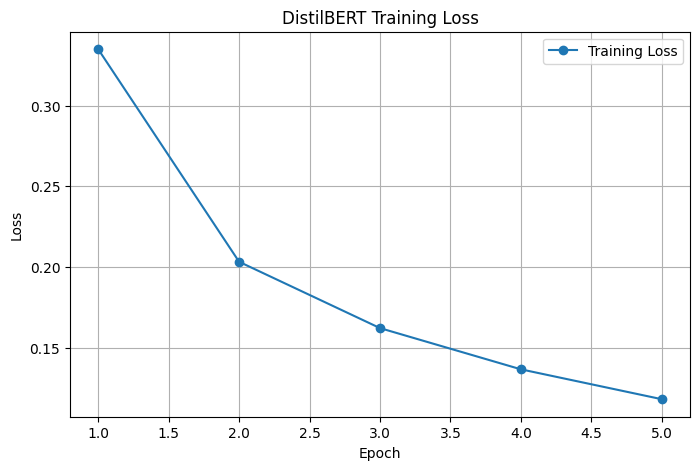

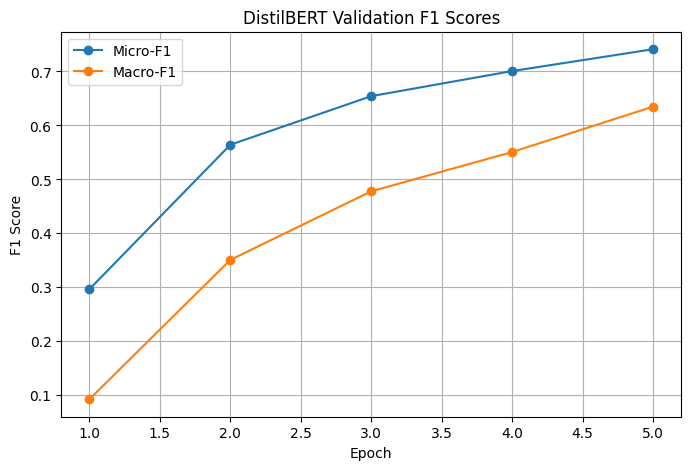

In [ ]:
# Plot training loss, Micro-F1, and Macro-F1 across epochs

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], marker="o", label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DistilBERT Training Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["micro_f1"], marker="o", label="Micro-F1")
plt.plot(history["epoch"], history["macro_f1"], marker="o", label="Macro-F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("DistilBERT Validation F1 Scores")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Evaluate the final DistilBERT model on the test set

model.eval()

test_predictions = []
test_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probabilities = torch.sigmoid(outputs.logits)
        predictions = (probabilities >= 0.5).int()

        test_predictions.append(predictions.cpu().numpy())
        test_labels.append(batch["labels"].numpy())

test_predictions = np.vstack(test_predictions)
test_labels = np.vstack(test_labels)

test_micro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="micro",
    zero_division=0
)

test_macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

print("Test Micro-F1:", test_micro_f1)
print("Test Macro-F1:", test_macro_f1)

Test Micro-F1: 0.7532359081419624
Test Macro-F1: 0.6475156514605485


In [ ]:
# Save the trained DistilBERT model and tokenizer

save_dir = "./results/distilbert_task1"

os.makedirs(save_dir, exist_ok=True)

model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print("Model saved to:", save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./results/distilbert_task1


# **TASK 2**

In [ ]:
# Load the saved FMA graph samples

from torch_geometric.loader import DataLoader as GeoDataLoader

graph_files = sorted(glob.glob("./data/processed/graphs/*.pt"))

graphs = [torch.load(path, weights_only=False) for path in graph_files]

print("Number of loaded graphs:", len(graphs))
print("First graph:", graphs[0])
print("First graph label:", graphs[0].y.item())

Number of loaded graphs: 26
First graph: Data(x=[5, 12], edge_index=[2, 12], y=[1], track_id=2)
First graph label: 3


In [ ]:
# Check how many saved graphs belong to each FMA genre

from collections import Counter

label_counts = Counter(graph.y.item() for graph in graphs)

id_to_genre = {v: k for k, v in genre_to_id.items()}

for label_id, count in sorted(label_counts.items()):
    print(f"{id_to_genre[label_id]}: {count}")

Hip-Hop: 2
Instrumental: 4
International: 10
Pop: 6
Rock: 4


In [ ]:
# Check FMA-small genre counts across the official train/validation/test splits

genre_split_counts = pd.crosstab(
    small[("track", "genre_top")],
    small[("set", "split")]
)

print(genre_split_counts)

('set', 'split')    test  training  validation
(track, genre_top)                            
Electronic           100       800         100
Experimental         100       800         100
Folk                 100       800         100
Hip-Hop              100       800         100
Instrumental         100       800         100
International        100       800         100
Pop                  100       800         100
Rock                 100       800         100


In [ ]:
# Select a balanced FMA subset using the official splits

TRAIN_PER_GENRE = 200
VAL_PER_GENRE = 50
TEST_PER_GENRE = 50

selected_tracks = []

for genre in genre_to_id.keys():
    genre_rows = small[small[("track", "genre_top")] == genre]

    train_rows = genre_rows[
        genre_rows[("set", "split")] == "training"
    ].head(TRAIN_PER_GENRE)

    val_rows = genre_rows[
        genre_rows[("set", "split")] == "validation"
    ].head(VAL_PER_GENRE)

    test_rows = genre_rows[
        genre_rows[("set", "split")] == "test"
    ].head(TEST_PER_GENRE)

    selected_tracks.extend(
        [(track_id, genre, "training") for track_id in train_rows.index]
    )

    selected_tracks.extend(
        [(track_id, genre, "validation") for track_id in val_rows.index]
    )

    selected_tracks.extend(
        [(track_id, genre, "test") for track_id in test_rows.index]
    )

print("Selected tracks:", len(selected_tracks))

Selected tracks: 2400


In [ ]:
# Generate balanced graph datasets for Task 2

from tqdm.auto import tqdm

task2_graph_dir = "./data/processed/task2_graphs"
os.makedirs(task2_graph_dir, exist_ok=True)

saved = 0
failed = 0

for track_id, genre, split in tqdm(selected_tracks):
    try:
        tid = f"{int(track_id):06d}"
        audio_path = f"./data/raw/fma/fma_small/{tid[:3]}/{tid}.mp3"

        features = preprocess_track(audio_path)

        temporal_edges = build_temporal_edges(len(features))
        similarity_edges = build_similarity_edges(features, threshold=0.997)

        edge_index = torch.cat(
            [temporal_edges, similarity_edges],
            dim=1
        )

        edge_index = torch.unique(edge_index, dim=1)

        graph = Data(
            x=torch.tensor(features, dtype=torch.float),
            edge_index=edge_index,
            y=torch.tensor([genre_to_id[genre]], dtype=torch.long)
        )

        graph.track_id = int(track_id)
        graph.split = split

        split_dir = os.path.join(task2_graph_dir, split)
        os.makedirs(split_dir, exist_ok=True)

        save_path = os.path.join(split_dir, f"{tid}.pt")
        torch.save(graph, save_path)

        saved += 1

    except Exception as e:
        failed += 1

print("Saved graphs:", saved)
print("Failed tracks:", failed)

  0%|          | 0/2400 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: Use

Saved graphs: 2400
Failed tracks: 0


In [ ]:
# Load the Task 2 training, validation, and test graphs

train_graph_files = sorted(glob.glob("./data/processed/task2_graphs/training/*.pt"))
val_graph_files = sorted(glob.glob("./data/processed/task2_graphs/validation/*.pt"))
test_graph_files = sorted(glob.glob("./data/processed/task2_graphs/test/*.pt"))

train_graphs = [torch.load(path, weights_only=False) for path in train_graph_files]
val_graphs = [torch.load(path, weights_only=False) for path in val_graph_files]
test_graphs = [torch.load(path, weights_only=False) for path in test_graph_files]

print("Training graphs:", len(train_graphs))
print("Validation graphs:", len(val_graphs))
print("Test graphs:", len(test_graphs))
print("Example graph:", train_graphs[0])

Training graphs: 1600
Validation graphs: 400
Test graphs: 400
Example graph: Data(x=[5, 12], edge_index=[2, 12], y=[1], track_id=2, split='training')


In [ ]:
# Create PyTorch Geometric DataLoaders

GNN_BATCH_SIZE = 32

train_gnn_loader = GeoDataLoader(
    train_graphs,
    batch_size=GNN_BATCH_SIZE,
    shuffle=True
)

val_gnn_loader = GeoDataLoader(
    val_graphs,
    batch_size=GNN_BATCH_SIZE,
    shuffle=False
)

test_gnn_loader = GeoDataLoader(
    test_graphs,
    batch_size=GNN_BATCH_SIZE,
    shuffle=False
)

batch = next(iter(train_gnn_loader))

print("Batch node features:", batch.x.shape)
print("Batch edges:", batch.edge_index.shape)
print("Batch labels:", batch.y.shape)
print("Number of graphs in batch:", batch.num_graphs)

Batch node features: torch.Size([173, 12])
Batch edges: torch.Size([2, 292])
Batch labels: torch.Size([32])
Number of graphs in batch: 32


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, global_mean_pool

class GraphSAGEModel(nn.Module):
    def __init__(self, input_dim=12, hidden_dim=64, num_classes=8):
        super().__init__()

        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)

        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(x, batch)

        return self.classifier(x)

gnn_model = GraphSAGEModel().to(device)

print(gnn_model)

GraphSAGEModel(
  (conv1): SAGEConv(12, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (classifier): Linear(in_features=64, out_features=8, bias=True)
)


In [ ]:
criterion = nn.BCEWithLogitsLoss()

gnn_optimizer = torch.optim.Adam(
    gnn_model.parameters(),
    lr=0.001
)

print("Loss:", criterion)
print("Optimizer ready")

Loss: BCEWithLogitsLoss()
Optimizer ready


In [ ]:
NUM_EPOCHS = 20

gnn_history = {
    "epoch": [],
    "train_loss": [],
    "val_accuracy": []
}

for epoch in range(1, NUM_EPOCHS + 1):
    gnn_model.train()
    total_loss = 0

    for batch in train_gnn_loader:
        batch = batch.to(device)

        gnn_optimizer.zero_grad()

        logits = gnn_model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        targets = F.one_hot(
            batch.y,
            num_classes=8
        ).float()

        loss = criterion(logits, targets)

        loss.backward()
        gnn_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_gnn_loader)

    gnn_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for batch in val_gnn_loader:
            batch = batch.to(device)

            logits = gnn_model(
                batch.x,
                batch.edge_index,
                batch.batch
            )

            predictions = torch.argmax(logits, dim=1)

            correct += (predictions == batch.y).sum().item()
            total += batch.y.size(0)

    val_accuracy = correct / total

    gnn_history["epoch"].append(epoch)
    gnn_history["train_loss"].append(avg_loss)
    gnn_history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch:02d} | "
        f"Loss: {avg_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch 01 | Loss: 0.4790 | Val Accuracy: 0.1250
Epoch 02 | Loss: 0.3782 | Val Accuracy: 0.1375
Epoch 03 | Loss: 0.3772 | Val Accuracy: 0.1325
Epoch 04 | Loss: 0.3764 | Val Accuracy: 0.1325
Epoch 05 | Loss: 0.3756 | Val Accuracy: 0.1775
Epoch 06 | Loss: 0.3750 | Val Accuracy: 0.1750
Epoch 07 | Loss: 0.3731 | Val Accuracy: 0.1600
Epoch 08 | Loss: 0.3721 | Val Accuracy: 0.1650
Epoch 09 | Loss: 0.3696 | Val Accuracy: 0.2350
Epoch 10 | Loss: 0.3679 | Val Accuracy: 0.2175
Epoch 11 | Loss: 0.3658 | Val Accuracy: 0.2275
Epoch 12 | Loss: 0.3643 | Val Accuracy: 0.2100
Epoch 13 | Loss: 0.3624 | Val Accuracy: 0.1675
Epoch 14 | Loss: 0.3618 | Val Accuracy: 0.2375
Epoch 15 | Loss: 0.3600 | Val Accuracy: 0.2200
Epoch 16 | Loss: 0.3602 | Val Accuracy: 0.2325
Epoch 17 | Loss: 0.3586 | Val Accuracy: 0.2200
Epoch 18 | Loss: 0.3581 | Val Accuracy: 0.2225
Epoch 19 | Loss: 0.3573 | Val Accuracy: 0.1975
Epoch 20 | Loss: 0.3573 | Val Accuracy: 0.2425


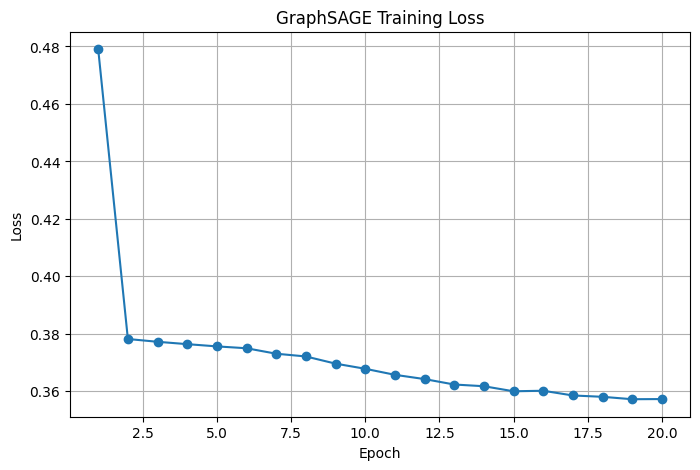

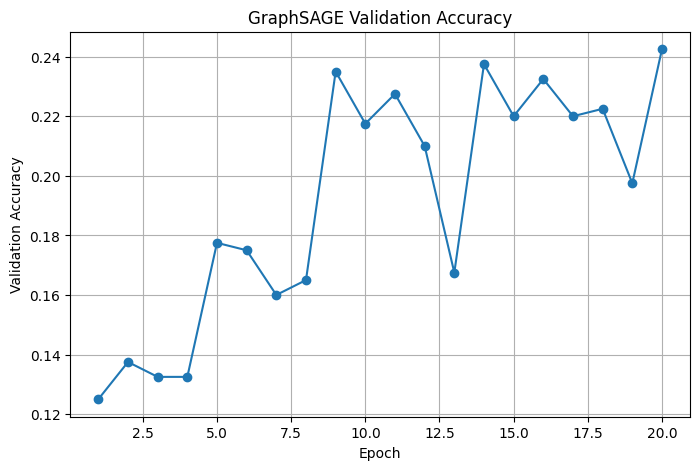

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    gnn_history["epoch"],
    gnn_history["train_loss"],
    marker="o"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GraphSAGE Training Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    gnn_history["epoch"],
    gnn_history["val_accuracy"],
    marker="o"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("GraphSAGE Validation Accuracy")
plt.grid(True)
plt.show()

In [ ]:
gnn_model.eval()

correct = 0
total = 0

all_test_predictions = []
all_test_labels = []

with torch.no_grad():
    for batch in test_gnn_loader:
        batch = batch.to(device)

        logits = gnn_model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        predictions = torch.argmax(logits, dim=1)

        correct += (predictions == batch.y).sum().item()
        total += batch.y.size(0)

        all_test_predictions.extend(predictions.cpu().numpy())
        all_test_labels.extend(batch.y.cpu().numpy())

test_accuracy = correct / total

print("Task 2 Test Accuracy:", test_accuracy)

Task 2 Test Accuracy: 0.25


In [ ]:
gnn_save_path = "./results/graphsage_task2.pt"

os.makedirs("./results", exist_ok=True)

torch.save(
    gnn_model.state_dict(),
    gnn_save_path
)

print("GraphSAGE model saved to:", gnn_save_path)

GraphSAGE model saved to: ./results/graphsage_task2.pt


In [ ]:
N_MELS = 128
MEL_DURATION = 10
TARGET_LENGTH = TARGET_SR * MEL_DURATION

def extract_log_mel(file_path):
    y, sr = librosa.load(
        file_path,
        sr=TARGET_SR,
        mono=True,
        duration=MEL_DURATION
    )

    if len(y) < TARGET_LENGTH:
        y = np.pad(y, (0, TARGET_LENGTH - len(y)))
    else:
        y = y[:TARGET_LENGTH]

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=N_MELS
    )

    log_mel = librosa.power_to_db(
        mel,
        ref=np.max
    )

    return log_mel

In [ ]:
sample_mel = extract_log_mel(sample_path)

print("Mel-spectrogram shape:", sample_mel.shape)

Mel-spectrogram shape: (128, 431)


In [ ]:
class FMAMelDataset(torch.utils.data.Dataset):
    def __init__(self, track_items):
        self.track_items = track_items

    def __len__(self):
        return len(self.track_items)

    def __getitem__(self, idx):
        track_id, genre, split = self.track_items[idx]

        tid = f"{int(track_id):06d}"
        audio_path = f"./data/raw/fma/fma_small/{tid[:3]}/{tid}.mp3"

        mel = extract_log_mel(audio_path)

        mel = (mel - mel.mean()) / (mel.std() + 1e-8)

        mel_tensor = torch.tensor(
            mel,
            dtype=torch.float
        ).unsqueeze(0)

        label = torch.tensor(
            genre_to_id[genre],
            dtype=torch.long
        )

        return mel_tensor, label
cnn_dataset_test = FMAMelDataset(selected_tracks)

sample_mel_tensor, sample_label = cnn_dataset_test[0]

print("Mel tensor shape:", sample_mel_tensor.shape)
print("Label:", sample_label.item())

Mel tensor shape: torch.Size([1, 128, 431])
Label: 0


In [ ]:
train_items = [item for item in selected_tracks if item[2] == "training"]
val_items = [item for item in selected_tracks if item[2] == "validation"]
test_items = [item for item in selected_tracks if item[2] == "test"]

train_cnn_dataset = FMAMelDataset(train_items)
val_cnn_dataset = FMAMelDataset(val_items)
test_cnn_dataset = FMAMelDataset(test_items)

CNN_BATCH_SIZE = 16

train_cnn_loader = torch.utils.data.DataLoader(
    train_cnn_dataset,
    batch_size=CNN_BATCH_SIZE,
    shuffle=True
)

val_cnn_loader = torch.utils.data.DataLoader(
    val_cnn_dataset,
    batch_size=CNN_BATCH_SIZE,
    shuffle=False
)

test_cnn_loader = torch.utils.data.DataLoader(
    test_cnn_dataset,
    batch_size=CNN_BATCH_SIZE,
    shuffle=False
)

print("CNN training samples:", len(train_cnn_dataset))
print("CNN validation samples:", len(val_cnn_dataset))
print("CNN test samples:", len(test_cnn_dataset))

CNN training samples: 1600
CNN validation samples: 400
CNN test samples: 400


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))

        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

cnn_model = SimpleCNN().to(device)

print(cnn_model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (fc1): Linear(in_features=1024, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=8, bias=True)
)


In [ ]:
cnn_criterion = nn.CrossEntropyLoss()

cnn_optimizer = torch.optim.Adam(
    cnn_model.parameters(),
    lr=0.001
)

print("CNN loss:", cnn_criterion)
print("CNN optimizer ready")

CNN loss: CrossEntropyLoss()
CNN optimizer ready


In [ ]:
# Train the CNN baseline

CNN_EPOCHS = 10

cnn_history = {
    "epoch": [],
    "train_loss": [],
    "val_accuracy": []
}

for epoch in range(1, CNN_EPOCHS + 1):
    cnn_model.train()
    total_loss = 0

    progress_bar = tqdm(
        train_cnn_loader,
        desc=f"Epoch {epoch}"
    )

    for inputs, labels in progress_bar:
        inputs = inputs.to(device)
        labels = labels.to(device)

        cnn_optimizer.zero_grad()

        outputs = cnn_model(inputs)
        loss = cnn_criterion(outputs, labels)

        loss.backward()
        cnn_optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    avg_loss = total_loss / len(train_cnn_loader)

    cnn_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_cnn_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = cnn_model(inputs)
            predictions = torch.argmax(outputs, dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    val_accuracy = correct / total

    cnn_history["epoch"].append(epoch)
    cnn_history["train_loss"].append(avg_loss)
    cnn_history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch:02d} | "
        f"Loss: {avg_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch 1:   0%|          | 0/100 [00:00<?, ?it/s]

[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1844] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!


Epoch 01 | Loss: 2.0453 | Val Accuracy: 0.1850


Epoch 2:   0%|          | 0/100 [00:00<?, ?it/s]

[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1844] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!


...

[src/libmpg123/layer3.c:INT123_do_layer3():1844] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!


Epoch 09 | Loss: 1.3868 | Val Accuracy: 0.4425


Epoch 10:   0%|          | 0/100 [00:00<?, ?it/s]

[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1844] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!


Epoch 10 | Loss: 1.3506 | Val Accuracy: 0.3950


In [ ]:
cnn_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_cnn_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = cnn_model(inputs)
        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

cnn_test_accuracy = correct / total

print("CNN Test Accuracy:", cnn_test_accuracy)

CNN Test Accuracy: 0.3875


In [ ]:
task2_results = pd.DataFrame({
    "Model": ["Random Chance", "GraphSAGE", "CNN Mel-Spectrogram"],
    "Test Accuracy": [0.1250, 0.2500, 0.3875]
})

print(task2_results)

                 Model  Test Accuracy
0        Random Chance         0.1250
1            GraphSAGE         0.2500
2  CNN Mel-Spectrogram         0.3875


In [ ]:
cnn_save_path = "./results/cnn_task2.pt"

torch.save(
    cnn_model.state_dict(),
    cnn_save_path
)

print("CNN model saved to:", cnn_save_path)

CNN model saved to: ./results/cnn_task2.pt


# **TASK 3**

In [ ]:
# Download MagnaTagATune metadata files

os.makedirs("./data/raw/magnatagatune", exist_ok=True)

!wget -q -O ./data/raw/magnatagatune/annotations_final.csv \
https://mirg.city.ac.uk/datasets/magnatagatune/annotations_final.csv

!wget -q -O ./data/raw/magnatagatune/clip_info_final.csv \
https://mirg.city.ac.uk/datasets/magnatagatune/clip_info_final.csv

print("MagnaTagATune metadata downloaded")

MagnaTagATune metadata downloaded


In [ ]:
mtt_annotations = pd.read_csv(
    "./data/raw/magnatagatune/annotations_final.csv",
    sep="\t"
)

print("Shape:", mtt_annotations.shape)
print("First columns:", mtt_annotations.columns[:15].tolist())

tag_columns = mtt_annotations.columns[1:-1]

tag_counts = mtt_annotations[tag_columns].sum().sort_values(
    ascending=False
)

print("\nNumber of tag columns:", len(tag_columns))
print("\nTop 30 tags:")
print(tag_counts.head(30))

Shape: (25863, 190)
First columns: ['clip_id', 'no voice', 'singer', 'duet', 'plucking', 'hard rock', 'world', 'bongos', 'harpsichord', 'female singing', 'clasical', 'sitar', 'chorus', 'female opera', 'male vocal']

Number of tag columns: 188

Top 30 tags:
guitar         4852
classical      4272
slow           3547
techno         2954
strings        2729
drums          2598
electronic     2519
rock           2371
fast           2306
piano          2056
ambient        1956
beat           1906
violin         1826
vocal          1729
synth          1717
female         1474
indian         1395
opera          1296
male           1279
singing        1211
vocals         1184
no vocals      1158
harpsichord    1093
loud           1086
quiet          1055
flute          1025
woman          1016
male vocal     1002
no vocal        995
pop             995
dtype: int64


In [ ]:
genre_tags = [
    "rock",
    "pop",
    "classical",
    "techno",
    "electronic",
    "ambient"
]

mood_tags = [
    "slow",
    "fast",
    "loud",
    "quiet"
]

task3_tags = genre_tags + mood_tags

mtt_task3 = mtt_annotations[
    mtt_annotations[task3_tags].sum(axis=1) > 0
].copy()

print("Selected labels:", task3_tags)
print("Usable clips:", len(mtt_task3))
print("\nLabel counts:")
print(mtt_task3[task3_tags].sum())

Selected labels: ['rock', 'pop', 'classical', 'techno', 'electronic', 'ambient', 'slow', 'fast', 'loud', 'quiet']
Usable clips: 14322

Label counts:
rock          2371
pop            995
classical     4272
techno        2954
electronic    2519
ambient       1956
slow          3547
fast          2306
loud          1086
quiet         1055
dtype: int64


In [ ]:
mtt_clip_info = pd.read_csv(
    "./data/raw/magnatagatune/clip_info_final.csv",
    sep="\t"
)

print("Clip info columns:", mtt_clip_info.columns.tolist())

mtt_task3 = mtt_task3.merge(
    mtt_clip_info,
    on="clip_id",
    how="left"
)

print("Merged shape:", mtt_task3.shape)
print(mtt_task3.head(3))

Clip info columns: ['clip_id', 'track_number', 'title', 'artist', 'album', 'url', 'segmentStart', 'segmentEnd', 'original_url', 'mp3_path']
Merged shape: (14322, 199)
   clip_id  no voice  singer  duet  plucking  hard rock  world  bongos  \
0        2         0       0     0         0          0      0       0   
1        6         0       0     0         0          0      0       0   
2       10         0       0     0         0          0      0       0   

   harpsichord  female singing  ...  \
0            0               0  ...   
1            0               0  ...   
2            0               0  ...   

                                          mp3_path_x  track_number  \
0  f/american_bach_soloists-j_s__bach_solo_cantat...             1   
1  f/american_bach_soloists-j_s__bach_solo_cantat...             1   
2  f/american_bach_soloists-j_s__bach_solo_cantat...             1   

            title                  artist                    album  \
0  BWV54 - I Aria  American 

In [ ]:
mtt_subset = mtt_task3.sample(
    n=1200,
    random_state=42
).reset_index(drop=True)

mtt_subset.to_csv(
    "./data/raw/magnatagatune/task3_subset.csv",
    index=False
)

print("Task 3 subset size:", len(mtt_subset))
print(mtt_subset[task3_tags].sum())

Task 3 subset size: 1200
rock          209
pop            80
classical     356
techno        262
electronic    214
ambient       148
slow          288
fast          189
loud           73
quiet          88
dtype: int64


In [ ]:
subset_paths = mtt_subset["mp3_path_y"].fillna(mtt_subset["mp3_path_x"])

prefix_counts = subset_paths.str[0].value_counts().sort_index()

print(prefix_counts)

mp3_path_y
0     62
1     68
2     76
3     37
4     97
5     70
6     91
7     56
8     49
9     96
a     67
b    101
c     76
d     78
e     71
f    105
Name: count, dtype: int64


In [ ]:
%cd ./data/raw/magnatagatune

!wget -nc https://mirg.city.ac.uk/datasets/magnatagatune/mp3.zip.001
!wget -nc https://mirg.city.ac.uk/datasets/magnatagatune/mp3.zip.002
!wget -nc https://mirg.city.ac.uk/datasets/magnatagatune/mp3.zip.003

!cat mp3.zip.001 mp3.zip.002 mp3.zip.003 > mp3.zip
!unzip -q mp3.zip

%cd /kaggle/working

print("MagnaTagATune audio extracted")

/kaggle/working/data/raw/magnatagatune
--2026-09-08 05:13:26--  https://mirg.city.ac.uk/datasets/magnatagatune/mp3.zip.001
Resolving mirg.city.ac.uk (mirg.city.ac.uk)... 138.40.249.131
Connecting to mirg.city.ac.uk (mirg.city.ac.uk)|138.40.249.131|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1100000000 (1.0G) [application/zip]
Saving to: ‘mp3.zip.001’

mp3.zip.001         100%[===================>]   1.02G  24.0MB/s    in 45s     

2026-09-08 05:14:11 (23.5 MB/s) - ‘mp3.zip.001’ saved [1100000000/1100000000]

--2026-09-08 05:14:11--  https://mirg.city.ac.uk/datasets/magnatagatune/mp3.zip.002
Resolving mirg.city.ac.uk (mirg.city.ac.uk)... 138.40.249.131
Connecting to mirg.city.ac.uk (mirg.city.ac.uk)|138.40.249.131|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1100000000 (1.0G) [application/zip]
Saving to: ‘mp3.zip.002’

mp3.zip.002         100%[===================>]   1.02G  23.6MB/s    in 45s     

2026-09-08 05:14:57 (23.5 MB/s

In [ ]:
import os, shutil

mtt_root = "./data/raw/magnatagatune"
subset_root = "./data/raw/magnatagatune/task3_audio"

os.makedirs(subset_root, exist_ok=True)

subset_paths = mtt_subset["mp3_path_y"].fillna(mtt_subset["mp3_path_x"])

copied = 0

for rel_path in subset_paths:
    src = os.path.join(mtt_root, rel_path)
    dst = os.path.join(subset_root, rel_path)

    if os.path.exists(src):
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy2(src, dst)
        copied += 1

print("Subset clips copied:", copied)

if copied == len(mtt_subset):
    for prefix in "0123456789abcdef":
        path = os.path.join(mtt_root, prefix)
        if os.path.isdir(path):
            shutil.rmtree(path)

    for name in ["mp3.zip", "mp3.zip.001", "mp3.zip.002", "mp3.zip.003"]:
        path = os.path.join(mtt_root, name)
        if os.path.exists(path):
            os.remove(path)

    print("Full archive removed safely.")

!df -h /kaggle/working

Subset clips copied: 1200
Full archive removed safely.
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  541M   19G   3% /kaggle/working


In [ ]:
def build_mtt_text(row):
    positive_tags = [
        tag for tag in tag_columns
        if tag not in task3_tags and row[tag] == 1
    ][:12]

    tag_text = ", ".join(positive_tags)

    return (
        f"Title: {row['title']}. "
        f"Artist: {row['artist']}. "
        f"Album: {row['album']}. "
        f"Musical characteristics: {tag_text}."
    )


mtt_subset["text"] = mtt_subset.apply(
    build_mtt_text,
    axis=1
)

mtt_subset["labels"] = mtt_subset[
    task3_tags
].values.tolist()

print("Task 3 text and labels prepared:", len(mtt_subset))

print("\nExample text:")
print(mtt_subset.iloc[0]["text"])

print(
    "Example labels:",
    mtt_subset.iloc[0]["labels"]
)

Task 3 text and labels prepared: 1200

Example text:
Title: Bisonpolska. Artist: Barry Phillips. Album: Trad. Musical characteristics: violins, strings, classic, violin.
Example labels: [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
import numpy as np
import librosa
import torch
from sklearn.metrics.pairwise import cosine_similarity

def preprocess_track(audio_path, target_sr=22050, segment_seconds=5):
    y, sr = librosa.load(
        audio_path,
        sr=target_sr,
        mono=True
    )

    segment_length = target_sr * segment_seconds
    features = []

    for start in range(0, len(y), segment_length):
        segment = y[start:start + segment_length]

        if len(segment) < segment_length:
            continue

        chroma = librosa.feature.chroma_stft(
            y=segment,
            sr=target_sr
        )

        feature = chroma.mean(axis=1)

        norm = np.linalg.norm(feature)

        if norm > 0:
            feature = feature / norm

        features.append(feature)

    return np.array(features)


def build_temporal_edges(num_nodes):
    edges = []

    for i in range(num_nodes - 1):
        edges.append([i, i + 1])
        edges.append([i + 1, i])

    return torch.tensor(
        edges,
        dtype=torch.long
    ).t().contiguous()


def build_similarity_edges(features, threshold=0.997):
    similarities = cosine_similarity(features)
    edges = []

    for i in range(len(features)):
        for j in range(i + 1, len(features)):

            if similarities[i, j] >= threshold:
                edges.append([i, j])
                edges.append([j, i])

    if len(edges) == 0:
        return torch.empty(
            (2, 0),
            dtype=torch.long
        )

    return torch.tensor(
        edges,
        dtype=torch.long
    ).t().contiguous()


print("Task 3 preprocessing helpers ready")

Task 3 preprocessing helpers ready


In [ ]:
from tqdm.auto import tqdm
import os
import glob
import shutil

task3_graph_root = "./data/processed/mtt_task3_graphs"

if os.path.exists(task3_graph_root):
    shutil.rmtree(task3_graph_root)

os.makedirs(task3_graph_root, exist_ok=True)


def mtt_audio_path(row):
    rel_path = row["mp3_path_y"]

    if pd.isna(rel_path):
        rel_path = row["mp3_path_x"]

    return os.path.join(
        "./data/raw/magnatagatune/task3_audio",
        rel_path
    )


def get_mtt_split(row):
    rel_path = row["mp3_path_y"]

    if pd.isna(rel_path):
        rel_path = row["mp3_path_x"]

    prefix = rel_path.split("/")[0].lower()

    if prefix in list("0123456789ab"):
        return "train"
    elif prefix == "c":
        return "val"
    elif prefix in list("def"):
        return "test"

    return None


mtt_subset["split"] = mtt_subset.apply(
    get_mtt_split,
    axis=1
)

train_mtt = mtt_subset[
    mtt_subset["split"] == "train"
].reset_index(drop=True)

val_mtt = mtt_subset[
    mtt_subset["split"] == "val"
].reset_index(drop=True)

test_mtt = mtt_subset[
    mtt_subset["split"] == "test"
].reset_index(drop=True)


print("Official MagnaTagATune split:")
print("Train:", len(train_mtt))
print("Validation:", len(val_mtt))
print("Test:", len(test_mtt))


def build_mtt_graph(row):
    audio_path = mtt_audio_path(row)

    if not os.path.isfile(audio_path):
        raise FileNotFoundError(audio_path)

    features = preprocess_track(audio_path)

    if len(features) < 2:
        raise ValueError("Not enough audio segments")

    temporal_edges = build_temporal_edges(
        len(features)
    )

    similarity_edges = build_similarity_edges(
        features,
        threshold=0.997
    )

    edge_index = torch.cat(
        [temporal_edges, similarity_edges],
        dim=1
    )

    edge_index = torch.unique(
        edge_index,
        dim=1
    )

    graph = Data(
        x=torch.tensor(
            features,
            dtype=torch.float
        ),
        edge_index=edge_index,
        y=torch.tensor(
            row[task3_tags].values.astype(float),
            dtype=torch.float
        )
    )

    graph.clip_id = int(row["clip_id"])

    return graph


split_data = {
    "train": train_mtt,
    "val": val_mtt,
    "test": test_mtt
}

summary = {}

for split_name, split_df in split_data.items():

    split_dir = os.path.join(
        task3_graph_root,
        split_name
    )

    os.makedirs(
        split_dir,
        exist_ok=True
    )

    saved = 0
    skipped = 0

    for _, row in tqdm(
        split_df.iterrows(),
        total=len(split_df),
        desc=split_name
    ):

        save_path = os.path.join(
            split_dir,
            f"{int(row['clip_id'])}.pt"
        )

        try:
            graph = build_mtt_graph(row)
            torch.save(graph, save_path)
            saved += 1

        except Exception:
            skipped += 1

    summary[split_name] = {
        "saved": saved,
        "skipped": skipped
    }


print("\nGraph generation complete")

for split_name in ["train", "val", "test"]:
    print(
        f"{split_name}: "
        f"{summary[split_name]['saved']} saved | "
        f"{summary[split_name]['skipped']} skipped"
    )

Official MagnaTagATune split:
Train: 870
Validation: 76
Test: 254


train:   0%|          | 0/870 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
/tmp/ipykernel_58/438711636.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


val:   0%|          | 0/76 [00:00<?, ?it/s]

test:   0%|          | 0/254 [00:00<?, ?it/s]


Graph generation complete
train: 869 saved | 1 skipped
val: 76 saved | 0 skipped
test: 254 saved | 0 skipped


In [ ]:
from torch_geometric.data import Batch

class MTTTask3Dataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, split_name, tokenizer, max_length=128):
        self.rows = []

        for _, row in dataframe.iterrows():
            graph_path = os.path.join(
                task3_graph_root,
                split_name,
                f"{int(row['clip_id'])}.pt"
            )

            if os.path.exists(graph_path):
                self.rows.append((row, graph_path))

        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row, graph_path = self.rows[idx]

        graph = torch.load(
            graph_path,
            weights_only=False
        )

        encoding = self.tokenizer(
            row["text"],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "graph": graph,
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(
                row[task3_tags].values.astype(float),
                dtype=torch.float
            )
        }


def mtt_collate(batch):
    return {
        "graph": Batch.from_data_list(
            [item["graph"] for item in batch]
        ),
        "input_ids": torch.stack(
            [item["input_ids"] for item in batch]
        ),
        "attention_mask": torch.stack(
            [item["attention_mask"] for item in batch]
        ),
        "labels": torch.stack(
            [item["labels"] for item in batch]
        )
    }


train_task3 = MTTTask3Dataset(
    train_mtt, "train", tokenizer
)

val_task3 = MTTTask3Dataset(
    val_mtt, "val", tokenizer
)

test_task3 = MTTTask3Dataset(
    test_mtt, "test", tokenizer
)

TASK3_BATCH_SIZE = 16

train_task3_loader = torch.utils.data.DataLoader(
    train_task3,
    batch_size=TASK3_BATCH_SIZE,
    shuffle=True,
    collate_fn=mtt_collate
)

val_task3_loader = torch.utils.data.DataLoader(
    val_task3,
    batch_size=TASK3_BATCH_SIZE,
    shuffle=False,
    collate_fn=mtt_collate
)

test_task3_loader = torch.utils.data.DataLoader(
    test_task3,
    batch_size=TASK3_BATCH_SIZE,
    shuffle=False,
    collate_fn=mtt_collate
)

batch = next(iter(train_task3_loader))

print("Train:", len(train_task3))
print("Validation:", len(val_task3))
print("Test:", len(test_task3))
print("Graph nodes:", batch["graph"].x.shape)
print("Text:", batch["input_ids"].shape)
print("Labels:", batch["labels"].shape)

Train: 869
Validation: 76
Test: 254
Graph nodes: torch.Size([80, 12])
Text: torch.Size([16, 128])
Labels: torch.Size([16, 10])


In [ ]:
MODEL_NAME = "distilbert-base-uncased"

print("MODEL_NAME:", MODEL_NAME)

MODEL_NAME: distilbert-base-uncased


In [ ]:
from torch_geometric.nn import SAGEConv, global_mean_pool
from transformers import AutoModel

class GNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = SAGEConv(12, 64)
        self.conv2 = SAGEConv(64, 64)

    def forward(self, graph):
        x = F.relu(self.conv1(graph.x, graph.edge_index))
        x = F.relu(self.conv2(x, graph.edge_index))

        return global_mean_pool(x, graph.batch)


class TextEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)

    def forward(self, input_ids, attention_mask, return_tokens=False):
        out = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        if return_tokens:
            return out.last_hidden_state

        return out.last_hidden_state[:, 0, :]


class Task3Model(nn.Module):
    def __init__(self, mode, num_labels=10):
        super().__init__()

        self.mode = mode
        self.gnn = GNNEncoder()
        self.text = TextEncoder()

        if mode == "bert":
            self.classifier = nn.Linear(768, num_labels)

        elif mode == "gnn":
            self.classifier = nn.Linear(64, num_labels)

        elif mode == "concat":
            self.classifier = nn.Sequential(
                nn.Linear(832, 256),
                nn.ReLU(),
                nn.Linear(256, num_labels)
            )

        elif mode == "cross":
            self.graph_proj = nn.Linear(64, 256)
            self.text_proj = nn.Linear(768, 256)

            self.attention = nn.MultiheadAttention(
                embed_dim=256,
                num_heads=4,
                batch_first=True
            )

            self.fusion = nn.Sequential(
                nn.Linear(512, 256),
                nn.ReLU()
            )

            self.classifier = nn.Linear(
                256,
                num_labels
            )

    def forward(self, graph, input_ids, attention_mask):

        if self.mode == "bert":
            text_embedding = self.text(
                input_ids,
                attention_mask
            )

            return self.classifier(
                text_embedding
            )

        if self.mode == "gnn":
            graph_embedding = self.gnn(
                graph
            )

            return self.classifier(
                graph_embedding
            )

        if self.mode == "concat":
            graph_embedding = self.gnn(
                graph
            )

            text_embedding = self.text(
                input_ids,
                attention_mask
            )

            fused = torch.cat(
                [
                    graph_embedding,
                    text_embedding
                ],
                dim=1
            )

            return self.classifier(
                fused
            )

        graph_embedding = self.gnn(
            graph
        )

        graph_embedding = self.graph_proj(
            graph_embedding
        )

        text_tokens = self.text(
            input_ids,
            attention_mask,
            return_tokens=True
        )

        text_tokens = self.text_proj(
            text_tokens
        )

        attended_text, _ = self.attention(
            query=graph_embedding.unsqueeze(1),
            key=text_tokens,
            value=text_tokens,
            key_padding_mask=~attention_mask.bool()
        )

        attended_text = attended_text.squeeze(1)

        z = self.fusion(
            torch.cat(
                [
                    graph_embedding,
                    attended_text
                ],
                dim=1
            )
        )

        return self.classifier(z)


models = {
    name: Task3Model(
        name,
        num_labels=len(task3_tags)
    ).to(device)

    for name in [
        "bert",
        "gnn",
        "concat",
        "cross"
    ]
}

print("Created:", list(models.keys()))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Created: ['bert', 'gnn', 'concat', 'cross']


In [ ]:
# Train and evaluate

from sklearn.metrics import f1_score, average_precision_score

task3_results = []

for name, model in models.items():

    print(f"\n===== {name.upper()} =====")

    criterion = nn.BCEWithLogitsLoss()

    lr = 1e-3 if name == "gnn" else 2e-5

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr
    )

    for epoch in range(1, 4):

        model.train()
        total_loss = 0

        progress = tqdm(
            train_task3_loader,
            desc=f"{name} Epoch {epoch}"
        )

        for batch in progress:

            graph = batch["graph"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()

            logits = model(
                graph,
                input_ids,
                attention_mask
            )

            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(
            f"Epoch {epoch} loss:",
            round(total_loss / len(train_task3_loader), 4)
        )

    model.eval()

    val_probs = []
    val_true = []

    with torch.no_grad():
        for batch in val_task3_loader:

            graph = batch["graph"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            logits = model(
                graph,
                input_ids,
                attention_mask
            )

            val_probs.append(
                torch.sigmoid(logits).cpu().numpy()
            )

            val_true.append(
                batch["labels"].numpy()
            )

    val_probs = np.vstack(val_probs)
    val_true = np.vstack(val_true)

    best_threshold = 0.5
    best_macro = -1

    for threshold in np.arange(0.05, 0.51, 0.01):

        preds = (
            val_probs >= threshold
        ).astype(int)

        macro = f1_score(
            val_true,
            preds,
            average="macro",
            zero_division=0
        )

        if macro > best_macro:
            best_macro = macro
            best_threshold = threshold

    test_probs = []
    test_true = []

    with torch.no_grad():
        for batch in test_task3_loader:

            graph = batch["graph"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            logits = model(
                graph,
                input_ids,
                attention_mask
            )

            test_probs.append(
                torch.sigmoid(logits).cpu().numpy()
            )

            test_true.append(
                batch["labels"].numpy()
            )

    test_probs = np.vstack(test_probs)
    test_true = np.vstack(test_true)

    test_preds = (
        test_probs >= best_threshold
    ).astype(int)

    micro = f1_score(
        test_true,
        test_preds,
        average="micro",
        zero_division=0
    )

    macro = f1_score(
        test_true,
        test_preds,
        average="macro",
        zero_division=0
    )

    auc_pr = average_precision_score(
        test_true,
        test_probs,
        average="macro"
    )

    task3_results.append({
        "Model": name,
        "Threshold": round(best_threshold, 2),
        "Micro-F1": micro,
        "Macro-F1": macro,
        "AUC-PR": auc_pr
    })

task3_results = pd.DataFrame(task3_results)

print("\nFINAL TASK 3 RESULTS")
print(task3_results)

os.makedirs("./results", exist_ok=True)

task3_results.to_csv(
    "./results/task3_results.csv",
    index=False
)

for name, model in models.items():
    torch.save(
        model.state_dict(),
        f"./results/task3_{name}.pt"
    )

print("\nTask 3 models and results saved")


===== BERT =====


bert Epoch 1:   0%|          | 0/55 [00:00<?, ?it/s]

Epoch 1 loss: 0.4146


bert Epoch 2:   0%|          | 0/55 [00:00<?, ?it/s]

Epoch 2 loss: 0.3054


...

Epoch 1 loss: 0.6028


cross Epoch 2:   0%|          | 0/55 [00:00<?, ?it/s]

Epoch 2 loss: 0.4405


cross Epoch 3:   0%|          | 0/55 [00:00<?, ?it/s]

Epoch 3 loss: 0.3834

FINAL TASK 3 RESULTS
    Model  Threshold  Micro-F1  Macro-F1    AUC-PR
0    bert       0.23  0.596421  0.516907  0.609643
1     gnn       0.05  0.274604  0.266956  0.218001
2  concat       0.20  0.543011  0.465720  0.559546
3   cross       0.17  0.379514  0.257163  0.336036

Task 3 models and results saved


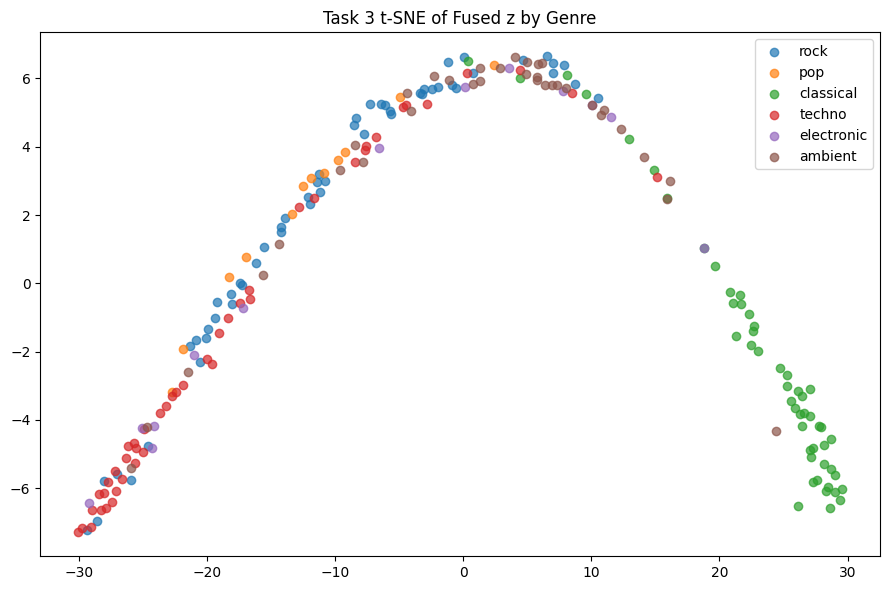

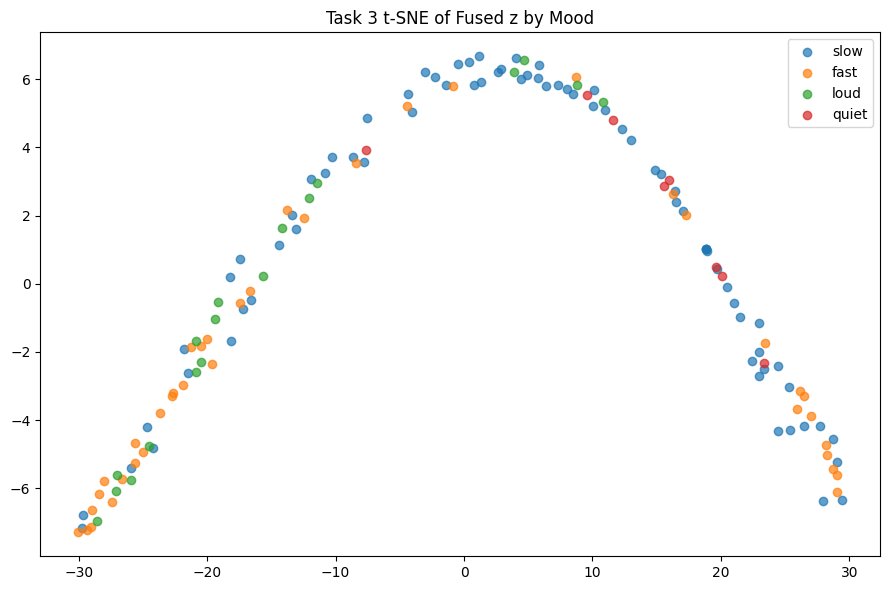

In [ ]:
from sklearn.manifold import TSNE

cross_model = models["cross"]
cross_model.eval()

embeddings = []
labels_all = []

with torch.no_grad():
    for batch in test_task3_loader:
        graph = batch["graph"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        g = cross_model.gnn(graph)
        g = cross_model.graph_proj(g)

        H_text = cross_model.text(
            input_ids,
            attention_mask,
            return_tokens=True
        )

        H_text = cross_model.text_proj(H_text)

        attended_text, _ = cross_model.attention(
            query=g.unsqueeze(1),
            key=H_text,
            value=H_text,
            key_padding_mask=~attention_mask.bool()
        )

        z = cross_model.fusion(
            torch.cat(
                [g, attended_text.squeeze(1)],
                dim=1
            )
        )

        embeddings.append(z.cpu().numpy())
        labels_all.append(batch["labels"].numpy())

embeddings = np.vstack(embeddings)
labels_all = np.vstack(labels_all)

tsne_xy = TSNE(
    n_components=2,
    perplexity=25,
    random_state=42
).fit_transform(embeddings)

genre_labels = labels_all[:, :6]
mood_labels = labels_all[:, 6:10]

genre_valid = genre_labels.sum(axis=1) > 0
mood_valid = mood_labels.sum(axis=1) > 0

genre_primary = np.argmax(
    genre_labels[genre_valid],
    axis=1
)

mood_primary = np.argmax(
    mood_labels[mood_valid],
    axis=1
)

plt.figure(figsize=(9, 6))

for i, name in enumerate(genre_tags):
    mask = genre_primary == i

    plt.scatter(
        tsne_xy[genre_valid][mask, 0],
        tsne_xy[genre_valid][mask, 1],
        label=name,
        alpha=0.7
    )

plt.title("Task 3 t-SNE of Fused z by Genre")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))

for i, name in enumerate(mood_tags):
    mask = mood_primary == i

    plt.scatter(
        tsne_xy[mood_valid][mask, 0],
        tsne_xy[mood_valid][mask, 1],
        label=name,
        alpha=0.7
    )

plt.title("Task 3 t-SNE of Fused z by Mood")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
cross_model = models["cross"]
cross_model.eval()

for case_id in range(3):
    row, graph_path = test_task3.rows[case_id]

    graph = torch.load(
        graph_path,
        weights_only=False
    )

    graph_batch = Batch.from_data_list([graph]).to(device)

    encoding = tokenizer(
        row["text"],
        truncation=True,
        padding="max_length",
        max_length=128,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        g = cross_model.gnn(graph_batch)
        g = cross_model.graph_proj(g)

        H_text = cross_model.text(
            input_ids,
            attention_mask,
            return_tokens=True
        )

        H_text = cross_model.text_proj(H_text)

        attended_text, weights = cross_model.attention(
            query=g.unsqueeze(1),
            key=H_text,
            value=H_text,
            key_padding_mask=~attention_mask.bool(),
            need_weights=True
        )

    weights = weights.squeeze().cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(
        input_ids.squeeze(0).cpu().tolist()
    )

    valid_len = int(attention_mask.sum().item())

    tokens = tokens[:valid_len]
    weights = weights[:valid_len]

    top_indices = np.argsort(weights)[::-1][:5]

    true_tags = [
        tag for tag in task3_tags
        if row[tag] == 1
    ]

    print(f"\nCASE STUDY {case_id + 1}")
    print("Text:", row["text"])
    print("True genre/mood tags:", true_tags)

    print(
        "Graph path:",
        " -> ".join(
            str(i) for i in range(graph.num_nodes)
        )
    )

    print("Top attended text tokens:")

    for idx in top_indices:
        print(
            f"{tokens[idx]} : {weights[idx]:.4f}"
        )


CASE STUDY 1
Text: Title: Skitzo_ Prom Night. Artist: Magnatune Compilation. Album: High Energy Rock and Roll. Musical characteristics: metal.
True genre/mood tags: ['rock']
Graph path: 0 -> 1 -> 2 -> 3 -> 4
Top attended text tokens:
title : 0.0323
prom : 0.0323
[CLS] : 0.0323
metal : 0.0323
##ne : 0.0323

CASE STUDY 2
Text: Title: Deluxe. Artist: Strojovna 07. Album: Switch On - Switch Off. Musical characteristics: electronica.
True genre/mood tags: ['techno']
Graph path: 0 -> 1 -> 2 -> 3 -> 4
Top attended text tokens:
[CLS] : 0.0358
title : 0.0358
##vna : 0.0358
. : 0.0357
##ro : 0.0357

CASE STUDY 3
Text: Title: Nightheat. Artist: Shiva In Exile. Album: Ethnic. Musical characteristics: .
True genre/mood tags: ['rock']
Graph path: 0 -> 1 -> 2 -> 3 -> 4
Top attended text tokens:
[CLS] : 0.0455
exile : 0.0455
##hea : 0.0455
title : 0.0455
. : 0.0455


# **TASK 4**

In [ ]:
!pip install -q librosa soundfile datasets yt-dlp matplotlib pandas torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 4.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 48.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.1 MB/s eta 0:00:00


In [ ]:
# Load the MusicCaps caption metadata

from datasets import load_dataset

musiccaps = load_dataset("google/MusicCaps")
caps_df = musiccaps["train"].to_pandas()

print("MusicCaps rows:", len(caps_df))
print(caps_df.columns.tolist())

caps_df[
    ["ytid", "start_s", "end_s", "caption"]
].head()

MusicCaps rows: 5521
['ytid', 'start_s', 'end_s', 'audioset_positive_labels', 'aspect_list', 'caption', 'author_id', 'is_balanced_subset', 'is_audioset_eval']


,ytid,start_s,end_s,caption
0,-0Gj8-vB1q4,30,40,The low quality recording features a ballad so...
1,-0SdAVK79lg,30,40,This song features an electric guitar as the m...
2,-0vPFx-wRRI,30,40,a male voice is singing a melody with changing...
3,-0xzrMun0Rs,30,40,This song contains digital drums playing a sim...
4,-1LrH01Ei1w,30,40,This song features a rubber instrument being p...


In [ ]:
from sklearn.model_selection import train_test_split

task4_df = caps_df.sample(
    n=300,
    random_state=42
).reset_index(drop=True)

task4_train, task4_temp = train_test_split(
    task4_df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

task4_val, task4_test = train_test_split(
    task4_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Task 4 subset:", len(task4_df))
print("Train:", len(task4_train))
print("Validation:", len(task4_val))
print("Test:", len(task4_test))

print("\nExample caption:")
print(task4_train.iloc[0]["caption"])

Task 4 subset: 300
Train: 240
Validation: 30
Test: 30

Example caption:
This is a Pamiri folk song. The female vocalist is singing melodically accompanied by a choir of both male and female back vocals. A keyboard is playing the main tune while a mixture of loud electronic drums and percussion provide the rhythmic background. This piece has a playful atmosphere. It could be used in a dancing course that involves folk dances of the region.


In [ ]:
import os
import subprocess
from tqdm.auto import tqdm

audio_dir = "./data/raw/musiccaps_task4"
os.makedirs(audio_dir, exist_ok=True)

downloaded = 0
failed = 0

for _, row in tqdm(task4_df.iterrows(), total=len(task4_df), desc="Downloading"):
    ytid = row["ytid"]
    start = int(row["start_s"])
    end = int(row["end_s"])

    output_path = os.path.join(audio_dir, f"{ytid}.wav")

    if os.path.exists(output_path):
        downloaded += 1
        continue

    url = f"https://www.youtube.com/watch?v={ytid}"

    temp_path = os.path.join(audio_dir, f"{ytid}.%(ext)s")

    try:
        subprocess.run(
            [
                "yt-dlp",
                "-q",
                "--no-warnings",
                "-f", "bestaudio",
                "-o", temp_path,
                url
            ],
            check=True
        )

        source_files = [
            f for f in os.listdir(audio_dir)
            if f.startswith(ytid) and not f.endswith(".wav")
        ]

        if not source_files:
            raise FileNotFoundError

        source_path = os.path.join(
            audio_dir,
            source_files[0]
        )

        subprocess.run(
            [
                "ffmpeg",
                "-loglevel", "error",
                "-y",
                "-ss", str(start),
                "-to", str(end),
                "-i", source_path,
                "-ar", "22050",
                "-ac", "1",
                output_path
            ],
            check=True
        )

        os.remove(source_path)

        downloaded += 1

    except Exception:
        failed += 1


print("Downloaded:", downloaded)
print("Failed:", failed)

Downloading:   0%|          | 0/300 [00:00<?, ?it/s]

ERROR: [youtube] QzO6ylLrTGg: Private video
ERROR: [youtube] ocCIB2bPq_Y: This video is unavailable
ERROR: [youtube] 4VbXYuCz4M0: This video is not available
ERROR: [youtube] nr9oLIsbDyQ: Private video
ERROR: [youtube] 2ZrqWkdwVzo: This video is not available
ERROR: [youtube] I1fcUe9MoMw: Please sign in. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dlp/yt-dlp/wiki/FAQ#how-do-i-pass-cookies-to-yt-dlp  for how to manually pass cookies. Also see  https://github.com/yt-dlp/yt-dlp/wiki/Extractors#exporting-youtube-cookies  for tips on effectively exporting YouTube cookies
ERROR: [youtube] tk4s-nlhmEQ: Video unavailable
ERROR: [youtube] HAHn_zB47ig: Private video
ERROR: [youtube] uGQ7QnKqeY4: This video is not available
ERROR: [youtube] idVCpQaByc4: We're processing this video. Check back later.
ERROR: [youtube] UdA6I_tXVHE: Video unavailable
ERROR: [youtube] opu2tXoVNKU: Video unavailable
ERROR: [youtube] bpwO0lbJPF4: This video is unavailable
E

Downloaded: 283
Failed: 17


In [ ]:
import os

task4_df = task4_df[
    task4_df["ytid"].apply(
        lambda ytid: os.path.exists(
            f"./data/raw/musiccaps_task4/{ytid}.wav"
        )
    )
].reset_index(drop=True)

task4_train, task4_temp = train_test_split(
    task4_df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

task4_val, task4_test = train_test_split(
    task4_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Usable Task 4 clips:", len(task4_df))
print("Train:", len(task4_train))
print("Validation:", len(task4_val))
print("Test:", len(task4_test))

Usable Task 4 clips: 283
Train: 226
Validation: 28
Test: 29


In [ ]:
!pip install -q torch-geometric

In [ ]:
import os
import torch
import librosa
import numpy as np
from tqdm.auto import tqdm
from torch_geometric.data import Data
from sklearn.metrics.pairwise import cosine_similarity

TARGET_SR = 22050
SEGMENT_SECONDS = 5
SIM_THRESHOLD = 0.997

task4_graph_dir = "./data/processed/musiccaps_task4_graphs"
os.makedirs(task4_graph_dir, exist_ok=True)


def preprocess_task4_audio(file_path):
    y, sr = librosa.load(
        file_path,
        sr=TARGET_SR,
        mono=True
    )

    segment_length = TARGET_SR * SEGMENT_SECONDS

    segments = []

    for start in range(0, len(y), segment_length):
        segment = y[start:start + segment_length]

        if len(segment) == segment_length:
            segments.append(segment)

    features = []

    for segment in segments:
        chroma = librosa.feature.chroma_stft(
            y=segment,
            sr=sr
        )

        features.append(
            chroma.mean(axis=1)
        )

    features = np.array(features)

    norms = np.linalg.norm(
        features,
        axis=1,
        keepdims=True
    )

    return features / (norms + 1e-8)


def build_task4_edges(features):
    edges = []

    for i in range(len(features) - 1):
        edges.append([i, i + 1])
        edges.append([i + 1, i])

    similarity = cosine_similarity(features)

    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            if similarity[i, j] >= SIM_THRESHOLD:
                edges.append([i, j])
                edges.append([j, i])

    return torch.tensor(
        edges,
        dtype=torch.long
    ).t().contiguous()


saved = 0
skipped = 0

for _, row in tqdm(
    task4_df.iterrows(),
    total=len(task4_df),
    desc="Building graphs"
):
    ytid = row["ytid"]

    audio_path = (
        f"./data/raw/musiccaps_task4/{ytid}.wav"
    )

    try:
        features = preprocess_task4_audio(
            audio_path
        )

        if len(features) < 2:
            skipped += 1
            continue

        edge_index = build_task4_edges(
            features
        )

        graph = Data(
            x=torch.tensor(
                features,
                dtype=torch.float
            ),
            edge_index=edge_index
        )

        graph.ytid = ytid

        torch.save(
            graph,
            os.path.join(
                task4_graph_dir,
                f"{ytid}.pt"
            )
        )

        saved += 1

    except Exception:
        skipped += 1


print("Graphs saved:", saved)
print("Skipped:", skipped)

Building graphs:   0%|          | 0/283 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Graphs saved: 266
Skipped: 17


In [ ]:
task4_df = task4_df[
    task4_df["ytid"].apply(
        lambda ytid: os.path.exists(
            f"./data/processed/musiccaps_task4_graphs/{ytid}.pt"
        )
    )
].reset_index(drop=True)

task4_train, task4_temp = train_test_split(
    task4_df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

task4_val, task4_test = train_test_split(
    task4_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Usable graph-caption pairs:", len(task4_df))
print("Train:", len(task4_train))
print("Validation:", len(task4_val))
print("Test:", len(task4_test))

Usable graph-caption pairs: 266
Train: 212
Validation: 27
Test: 27


In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Batch
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")


class MusicCapsGraphTextDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        graph = torch.load(
            f"./data/processed/musiccaps_task4_graphs/{row['ytid']}.pt",
            weights_only=False
        )

        tokens = tokenizer(
            row["caption"],
            max_length=128,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "graph": graph,
            "input_ids": tokens["input_ids"].squeeze(0),
            "attention_mask": tokens["attention_mask"].squeeze(0),
            "ytid": row["ytid"]
        }


def task4_collate(batch):
    graphs = Batch.from_data_list(
        [item["graph"] for item in batch]
    )

    input_ids = torch.stack(
        [item["input_ids"] for item in batch]
    )

    attention_mask = torch.stack(
        [item["attention_mask"] for item in batch]
    )

    ytids = [item["ytid"] for item in batch]

    return graphs, input_ids, attention_mask, ytids


train_dataset = MusicCapsGraphTextDataset(task4_train)
val_dataset = MusicCapsGraphTextDataset(task4_val)
test_dataset = MusicCapsGraphTextDataset(task4_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=task4_collate
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=task4_collate
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=task4_collate
)

graphs, input_ids, attention_mask, ytids = next(iter(train_loader))

print("Graph batch:", graphs)
print("Text shape:", input_ids.shape)
print("Attention mask shape:", attention_mask.shape)
print("Batch size:", len(ytids))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Graph batch: DataBatch(x=[32, 12], edge_index=[2, 36], ytid=[16], batch=[32], ptr=[17])
Text shape: torch.Size([16, 128])
Attention mask shape: torch.Size([16, 128])
Batch size: 16


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, global_mean_pool
from transformers import AutoModel


class AudioGNNEncoder(nn.Module):
    def __init__(self, hidden_dim=128, out_dim=128):
        super().__init__()

        self.conv1 = SAGEConv(12, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.proj = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        x = F.relu(
            self.conv1(graph.x, graph.edge_index)
        )

        x = F.relu(
            self.conv2(x, graph.edge_index)
        )

        x = global_mean_pool(
            x,
            graph.batch
        )

        x = self.proj(x)

        return F.normalize(x, dim=1)


class CaptionBERTEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()

        self.bert = AutoModel.from_pretrained(
            "distilbert-base-uncased"
        )

        self.proj = nn.Linear(
            self.bert.config.hidden_size,
            out_dim
        )

    def forward(self, input_ids, attention_mask):
        output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        text_embedding = output.last_hidden_state[:, 0]

        text_embedding = self.proj(
            text_embedding
        )

        return F.normalize(
            text_embedding,
            dim=1
        )


class Task4ContrastiveModel(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()

        self.audio_encoder = AudioGNNEncoder(
            out_dim=embedding_dim
        )

        self.text_encoder = CaptionBERTEncoder(
            out_dim=embedding_dim
        )

    def forward(
        self,
        graph,
        input_ids,
        attention_mask
    ):
        audio_embedding = self.audio_encoder(
            graph
        )

        text_embedding = self.text_encoder(
            input_ids,
            attention_mask
        )

        return audio_embedding, text_embedding

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Task4ContrastiveModel(
    embedding_dim=128
).to(device)

graphs, input_ids, attention_mask, ytids = next(iter(train_loader))

graphs = graphs.to(device)
input_ids = input_ids.to(device)
attention_mask = attention_mask.to(device)

with torch.no_grad():
    audio_embedding, text_embedding = model(
        graphs,
        input_ids,
        attention_mask
    )

print("Device:", device)
print("Audio embedding shape:", audio_embedding.shape)
print("Text embedding shape:", text_embedding.shape)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda
Audio embedding shape: torch.Size([16, 128])
Text embedding shape: torch.Size([16, 128])


In [ ]:
def contrastive_loss(audio_embeddings, text_embeddings, temperature=0.07):
    logits = audio_embeddings @ text_embeddings.T
    logits = logits / temperature

    labels = torch.arange(
        logits.size(0),
        device=logits.device
    )

    audio_to_text_loss = F.cross_entropy(
        logits,
        labels
    )

    text_to_audio_loss = F.cross_entropy(
        logits.T,
        labels
    )

    return (
        audio_to_text_loss + text_to_audio_loss
    ) / 2

In [ ]:
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()

    total_loss = 0

    for graphs, input_ids, attention_mask, ytids in train_loader:
        graphs = graphs.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        optimizer.zero_grad()

        audio_embedding, text_embedding = model(
            graphs,
            input_ids,
            attention_mask
        )

        loss = contrastive_loss(
            audio_embedding,
            text_embedding
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} - Loss: {avg_loss:.4f}"
    )

Epoch 1/5 - Loss: 2.7020
Epoch 2/5 - Loss: 2.6369
Epoch 3/5 - Loss: 2.5719
Epoch 4/5 - Loss: 2.4362
Epoch 5/5 - Loss: 2.2486


In [ ]:
model.eval()

all_audio = []
all_text = []

with torch.no_grad():
    for graphs, input_ids, attention_mask, ytids in test_loader:
        graphs = graphs.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        audio_emb, text_emb = model(
            graphs,
            input_ids,
            attention_mask
        )

        all_audio.append(audio_emb.cpu())
        all_text.append(text_emb.cpu())

audio_embeddings = torch.cat(all_audio, dim=0)
text_embeddings = torch.cat(all_text, dim=0)

similarity = text_embeddings @ audio_embeddings.T


def recall_at_k(similarity_matrix, k):
    correct = 0

    for i in range(similarity_matrix.size(0)):
        topk = torch.topk(
            similarity_matrix[i],
            k=min(k, similarity_matrix.size(1))
        ).indices

        if i in topk:
            correct += 1

    return correct / similarity_matrix.size(0)


caption_to_audio_r1 = recall_at_k(similarity, 1)
caption_to_audio_r5 = recall_at_k(similarity, 5)
caption_to_audio_r10 = recall_at_k(similarity, 10)

audio_to_caption_similarity = similarity.T

audio_to_caption_r1 = recall_at_k(audio_to_caption_similarity, 1)
audio_to_caption_r5 = recall_at_k(audio_to_caption_similarity, 5)
audio_to_caption_r10 = recall_at_k(audio_to_caption_similarity, 10)

print("Caption -> Audio")
print("R@1 :", round(caption_to_audio_r1, 4))
print("R@5 :", round(caption_to_audio_r5, 4))
print("R@10:", round(caption_to_audio_r10, 4))

print("\nAudio -> Caption")
print("R@1 :", round(audio_to_caption_r1, 4))
print("R@5 :", round(audio_to_caption_r5, 4))
print("R@10:", round(audio_to_caption_r10, 4))

Caption -> Audio
R@1 : 0.0
R@5 : 0.2963
R@10: 0.5185

Audio -> Caption
R@1 : 0.037
R@5 : 0.1481
R@10: 0.4444


In [ ]:
test_rows = task4_test.reset_index(drop=True)

for query_idx in range(min(10, len(test_rows))):
    scores = similarity[query_idx]

    top3 = torch.topk(
        scores,
        k=3
    ).indices.tolist()

    print("=" * 80)
    print(f"Query {query_idx + 1}")
    print("Caption:")
    print(test_rows.iloc[query_idx]["caption"])

    print("\nTop 3 retrieved clips:")

    for rank, idx in enumerate(top3, start=1):
        retrieved_ytid = test_rows.iloc[idx]["ytid"]

        correct = "✓ MATCH" if idx == query_idx else ""

        print(
            f"{rank}. {retrieved_ytid} "
            f"(score={scores[idx]:.4f}) {correct}"
        )

Query 1
Caption:
This recording contains gargling noises to which a lot of female voices sing along. In the background you can hear a full pop song that serves as background music. The recording is full of fast popping noises. This seems to be an amateur recording.

Top 3 retrieved clips:
1. mtapmFDmImA (score=0.1188) 
2. lh6ACdwNlyk (score=0.0643) 
3. PE1ges9nn6A (score=0.0492) 
Query 2
Caption:
The music features a female voice singing a long note melody for the first half of the excerpt. The drums play a steady rhythm and together with the bass guitar and tambourine drive the pulse of the music. A synth sound is playing a wobbly melody.

Top 3 retrieved clips:
1. N_LKZjw9DLk (score=0.1142) 
2. lh6ACdwNlyk (score=0.1040) 
3. ZEuY5HnECuo (score=0.1016) 
Query 3
Caption:
The low quality recording features a rock song that consists of an electric guitar melody, smooth bass, shimmering shakers, snappy rimshots and soft male vocals singing over it. The recording is really noisy and in mon

In [ ]:
import os

os.makedirs("./results", exist_ok=True)

torch.save(
    model.state_dict(),
    "./results/task4_contrastive_model.pt"
)

print("Task 4 model saved")

Task 4 model saved


In [ ]:
import pandas as pd
import os

os.makedirs("./results", exist_ok=True)

task4_results = pd.DataFrame({
    "Direction": [
        "Caption -> Audio",
        "Audio -> Caption"
    ],
    "R@1": [
        caption_to_audio_r1,
        audio_to_caption_r1
    ],
    "R@5": [
        caption_to_audio_r5,
        audio_to_caption_r5
    ],
    "R@10": [
        caption_to_audio_r10,
        audio_to_caption_r10
    ]
})

task4_results.to_csv(
    "./results/task4_retrieval_metrics.csv",
    index=False
)

task4_results

,Direction,R@1,R@5,R@10
0,Caption -> Audio,0.000000,0.296296,0.518519
1,Audio -> Caption,0.037037,0.148148,0.444444


In [ ]:
retrieval_rows = []

test_rows = task4_test.reset_index(drop=True)

for query_idx in range(min(10, len(test_rows))):
    scores = similarity[query_idx]
    top3 = torch.topk(scores, k=3).indices.tolist()

    for rank, idx in enumerate(top3, start=1):
        retrieval_rows.append({
            "query_number": query_idx + 1,
            "query_caption": test_rows.iloc[query_idx]["caption"],
            "rank": rank,
            "retrieved_ytid": test_rows.iloc[idx]["ytid"],
            "similarity_score": float(scores[idx]),
            "correct_match": idx == query_idx
        })

retrieval_examples_df = pd.DataFrame(retrieval_rows)

retrieval_examples_df.to_csv(
    "./results/task4_qualitative_retrievals.csv",
    index=False
)

print("Saved qualitative retrieval examples:", len(retrieval_examples_df))

Saved qualitative retrieval examples: 30


In [ ]:
os.makedirs("./data/splits", exist_ok=True)

task4_train.to_csv(
    "./data/splits/task4_train.csv",
    index=False
)

task4_val.to_csv(
    "./data/splits/task4_val.csv",
    index=False
)

task4_test.to_csv(
    "./data/splits/task4_test.csv",
    index=False
)

print("Task 4 splits saved")

Task 4 splits saved


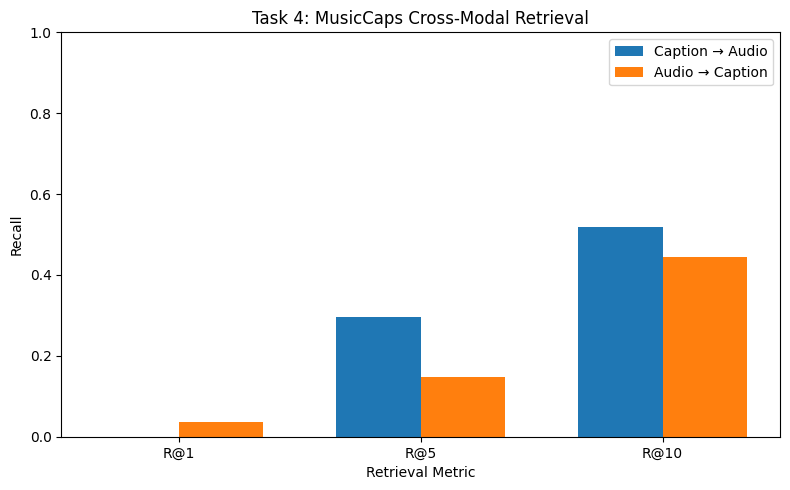

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["R@1", "R@5", "R@10"]

caption_audio = [
    caption_to_audio_r1,
    caption_to_audio_r5,
    caption_to_audio_r10
]

audio_caption = [
    audio_to_caption_r1,
    audio_to_caption_r5,
    audio_to_caption_r10
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    caption_audio,
    width,
    label="Caption → Audio"
)

plt.bar(
    x + width / 2,
    audio_caption,
    width,
    label="Audio → Caption"
)

plt.xticks(x, metrics)
plt.ylabel("Recall")
plt.xlabel("Retrieval Metric")
plt.title("Task 4: MusicCaps Cross-Modal Retrieval")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

os.makedirs("./results/plots", exist_ok=True)

plt.savefig(
    "./results/plots/task4_retrieval_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
task4_tags = [
    "rock",
    "pop",
    "classical",
    "techno",
    "electronic",
    "ambient",
    "slow",
    "fast",
    "loud",
    "quiet"
]

tag_prompts = [
    f"This music can be described as {tag}."
    for tag in task4_tags
]

for tag, prompt in zip(task4_tags, tag_prompts):
    print(tag, "->", prompt)

rock -> This music can be described as rock.
pop -> This music can be described as pop.
classical -> This music can be described as classical.
techno -> This music can be described as techno.
electronic -> This music can be described as electronic.
ambient -> This music can be described as ambient.
slow -> This music can be described as slow.
fast -> This music can be described as fast.
loud -> This music can be described as loud.
quiet -> This music can be described as quiet.


In [ ]:
task4_model = Task4ContrastiveModel(
    embedding_dim=128
).to(device)

task4_model.load_state_dict(
    torch.load(
        "./results/task4_contrastive_model.pt",
        map_location=device
    )
)

task4_model.eval()

print("Task 4 model loaded successfully")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Task 4 model loaded successfully


In [ ]:
task4_model.eval()

tag_tokens = tokenizer(
    tag_prompts,
    max_length=128,
    padding="max_length",
    truncation=True,
    return_tensors="pt"
)

tag_input_ids = tag_tokens["input_ids"].to(device)
tag_attention_mask = tag_tokens["attention_mask"].to(device)

with torch.no_grad():
    tag_embeddings = task4_model.text_encoder(
        tag_input_ids,
        tag_attention_mask
    )

zero_shot_rows = []

for _, row in test_rows.iterrows():

    caption_tokens = tokenizer(
        row["caption"],
        max_length=128,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    caption_input_ids = caption_tokens["input_ids"].to(device)
    caption_attention_mask = caption_tokens["attention_mask"].to(device)

    with torch.no_grad():
        caption_embedding = task4_model.text_encoder(
            caption_input_ids,
            caption_attention_mask
        )

    scores = (
        caption_embedding @ tag_embeddings.T
    ).squeeze(0)

    top3 = torch.topk(
        scores,
        k=3
    ).indices.tolist()

    predicted_tags = [
        task4_tags[idx]
        for idx in top3
    ]

    zero_shot_rows.append({
        "ytid": row["ytid"],
        "caption": row["caption"],
        "predicted_tag_1": predicted_tags[0],
        "predicted_tag_2": predicted_tags[1],
        "predicted_tag_3": predicted_tags[2]
    })

zero_shot_df = pd.DataFrame(zero_shot_rows)

zero_shot_df.to_csv(
    "./results/task4_zero_shot_predictions.csv",
    index=False
)

print(zero_shot_df.head(10))
print("\nSaved:", len(zero_shot_df), "zero-shot predictions")

          ytid                                            caption  \
0  nSBDyxxscks  This recording contains gargling noises to whi...   
1  PE1ges9nn6A  The music features a female voice singing a lo...   
2  hOSzGYKaJGE  The low quality recording features a rock song...   
3  K1PzpuR6CqY  This is a swing jazz music performance. The ma...   
4  XgXOW3lX25Y  This hard rock song features a distortion guit...   
5  P39x5dOsJ40  The low quality recording features a drummer p...   
6  fAfk9yrGhWw  This instrumental song features a guitar playi...   
7  AzhfZ8rNhRk  This is the noise of a fire alarm with rock mu...   
8  9oiSwXk8Nsk  This reggaeton song features a male voice sing...   
9  dsU3B0W3TMs  The music features a glockenspiel playing a me...   

  predicted_tag_1 predicted_tag_2 predicted_tag_3  
0           quiet            loud            fast  
1      electronic            fast           quiet  
2          techno             pop            rock  
3       classical            fas

In [ ]:
zero_shot_df.to_csv(
    "./results/task4_zero_shot_predictions.csv",
    index=False
)

print("Zero-shot predictions saved:", len(zero_shot_df))

Zero-shot predictions saved: 27


In [ ]:
task3_supervised = pd.read_csv(
    "./results/task3_results.csv"
)

best_task3 = task3_supervised.loc[
    task3_supervised["Macro-F1"].idxmax()
]

comparison_df = pd.DataFrame([
    {
        "Method": "Task 3 Supervised",
        "Model": best_task3["Model"],
        "Macro-F1": best_task3["Macro-F1"],
        "AUC-PR": best_task3["AUC-PR"],
        "Setting": "Supervised multi-label classification"
    },
    {
        "Method": "Task 4 Zero-shot",
        "Model": "GNN-BERT contrastive",
        "Macro-F1": "N/A",
        "AUC-PR": "N/A",
        "Setting": "Caption-to-tag similarity, no tag supervision"
    }
])

comparison_df.to_csv(
    "./results/task3_vs_task4_zero_shot.csv",
    index=False
)

print(comparison_df)

              Method                 Model  Macro-F1    AUC-PR  \
0  Task 3 Supervised                  bert  0.516907  0.609643   
1   Task 4 Zero-shot  GNN-BERT contrastive       N/A       N/A   

                                         Setting  
0          Supervised multi-label classification  
1  Caption-to-tag similarity, no tag supervision  


In [ ]:
#Human Evaluation
human_eval = pd.DataFrame({
    "Query": [1, 2, 3, 4, 5],
    "Listener_1": [4, 3, 4, 2, 4],
    "Listener_2": [3, 4, 4, 3, 5],
    "Listener_3": [4, 3, 5, 3, 4],
    "Listener_4": [4, 4, 3, 2, 4],
    "Listener_5": [3, 4, 4, 3, 5]
})

listener_cols = [
    "Listener_1",
    "Listener_2",
    "Listener_3",
    "Listener_4",
    "Listener_5"
]

human_eval["Average"] = human_eval[listener_cols].mean(axis=1)

overall_average = human_eval["Average"].mean()

print(human_eval)
print("\nOverall average rating:", round(overall_average, 2))

   Query  Listener_1  Listener_2  Listener_3  Listener_4  Listener_5  Average
0      1           4           3           4           4           3      3.6
1      2           3           4           3           4           4      3.6
2      3           4           4           5           3           4      4.0
3      4           2           3           3           2           3      2.6
4      5           4           5           4           4           5      4.4

Overall average rating: 3.64
